# Task 3 — OSDR batch effects in expression and frozen BridgeRNA

**Question.** Are the mission/library-preparation effects reported by Sanders et al. retained, reduced, or reorganized in frozen BridgeRNA sample embeddings?

This notebook is the primary report. It uses exactly the seven studies and 112 FLT/GC liver samples in Figure 1, performs no batch correction, and intentionally stops before response-vector, attribution, or pathway analyses.

Reference: Sanders LM et al. (2023), *Frontiers in Astronomy and Space Sciences* 10:1200132, [doi:10.3389/fspas.2023.1200132](https://doi.org/10.3389/fspas.2023.1200132).

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
from IPython.display import Image, Markdown, display
HERE = Path.cwd()
if HERE.name != 'osdr_batch_effect_representation':
    HERE = HERE / 'benchmarks/osdr_batch_effect_representation'
R = HERE / 'results'
manifest = pd.read_csv(R / 'sample_manifest.csv')
cohort = pd.read_csv(R / 'cohort_summary.csv')
structure = pd.read_csv(R / 'categorical_structure_summary.csv')
pc_structure = pd.read_csv(R / 'pc_categorical_associations.csv')
expr_var = pd.read_csv(R / 'expression_pca_variance.csv')
fm_var = pd.read_csv(R / 'bridgerna_pca_variance.csv')
provenance = json.loads((R / 'provenance.json').read_text())

## 1. Paper protocol and reproducibility boundary

Sanders et al. combined unnormalized count tables from OSD-47, -48, -137, -168, -173, -242, and -245; inner-joined Ensembl genes; retained only flight and respective ground controls; applied DESeq2 median-of-ratios normalization; and ran centered, unscaled R `prcomp()`. Figure 1 reports PC1 = 25.2% and PC2 = 12.75%.

The article does **not explicitly document a log transformation** between DESeq2 normalization and PCA. However, direct PCA of normalized counts gives PC1/PC2 = 84.67%/12.07%, whereas `log2(normalized counts + 1)` gives approximately 24.69%/12.73%, nearly reproducing the published values. We therefore use the latter for the matched reproduction and clearly label it as an empirically inferred processing step—not a directly reported method. No batch correction is applied.

In [2]:
display(Markdown((R / 'reproduction_notes.md').read_text()))

# Reproduction notes

- Sanders et al. report 112 liver samples: 57 FLT and 55 GC. This pipeline matches those totals exactly.
- The seven local GeneLab unnormalized count tables were restricted to FLT and respective GC samples.
- Counts were inner-joined on version-stripped Ensembl IDs, retaining 51,929 genes.
- The paper states DESeq2 v1.30.1 median-of-ratios normalization, followed by R `prcomp()` v4.1.0. Local R does not have DESeq2, so its default `ratio` size-factor algorithm was reproduced directly: genes containing any zero were excluded from geometric-mean estimation; each sample size factor is the median ratio to gene geometric means. 13,609 genes contributed to size-factor estimation.
- Before PCA, we apply `log2(DESeq2-normalized counts + 1)`, then centered, unscaled PCA matching `prcomp(center=TRUE, scale.=FALSE)`. The article does not explicitly state the log step, but it is required to reproduce Figure 1's reported variance: our PC1/PC2 are 24.69%/12.73%, versus 25.2%/12.75% in the paper. This inferred step is disclosed rather than presented as directly documented. No batch correction is applied.
- Mission assignments for multi-mission OSD-168 and OSD-245 use sample-name mission/return annotations consistent with Table 1: OSD-168 RR3 versus RR1 NASA; OSD-245 ISS-T as RR3 versus LAR as RR6.
- The supplementary payload filenames are declared in the publisher XML, but direct publisher downloads returned 404 during this run. The local OSDR sample metadata plus paper Table 1 were therefore used; this limitation is explicit.
- BridgeRNA inputs are independently generated as mouse-annotation TPM, mapped to the frozen 15,165 one-to-one vocabulary, then natural log1p(TPM). The exact same 112 samples are used, but this representation necessarily uses the model's native preprocessing rather than DESeq2-normalized full counts.
- BridgeRNA is frozen; sample embeddings are 512-D mean-pooled contextual representations. No correction, alignment, fine-tuning, or target-label use occurs.


### Published Figure 1 and matched local reproduction

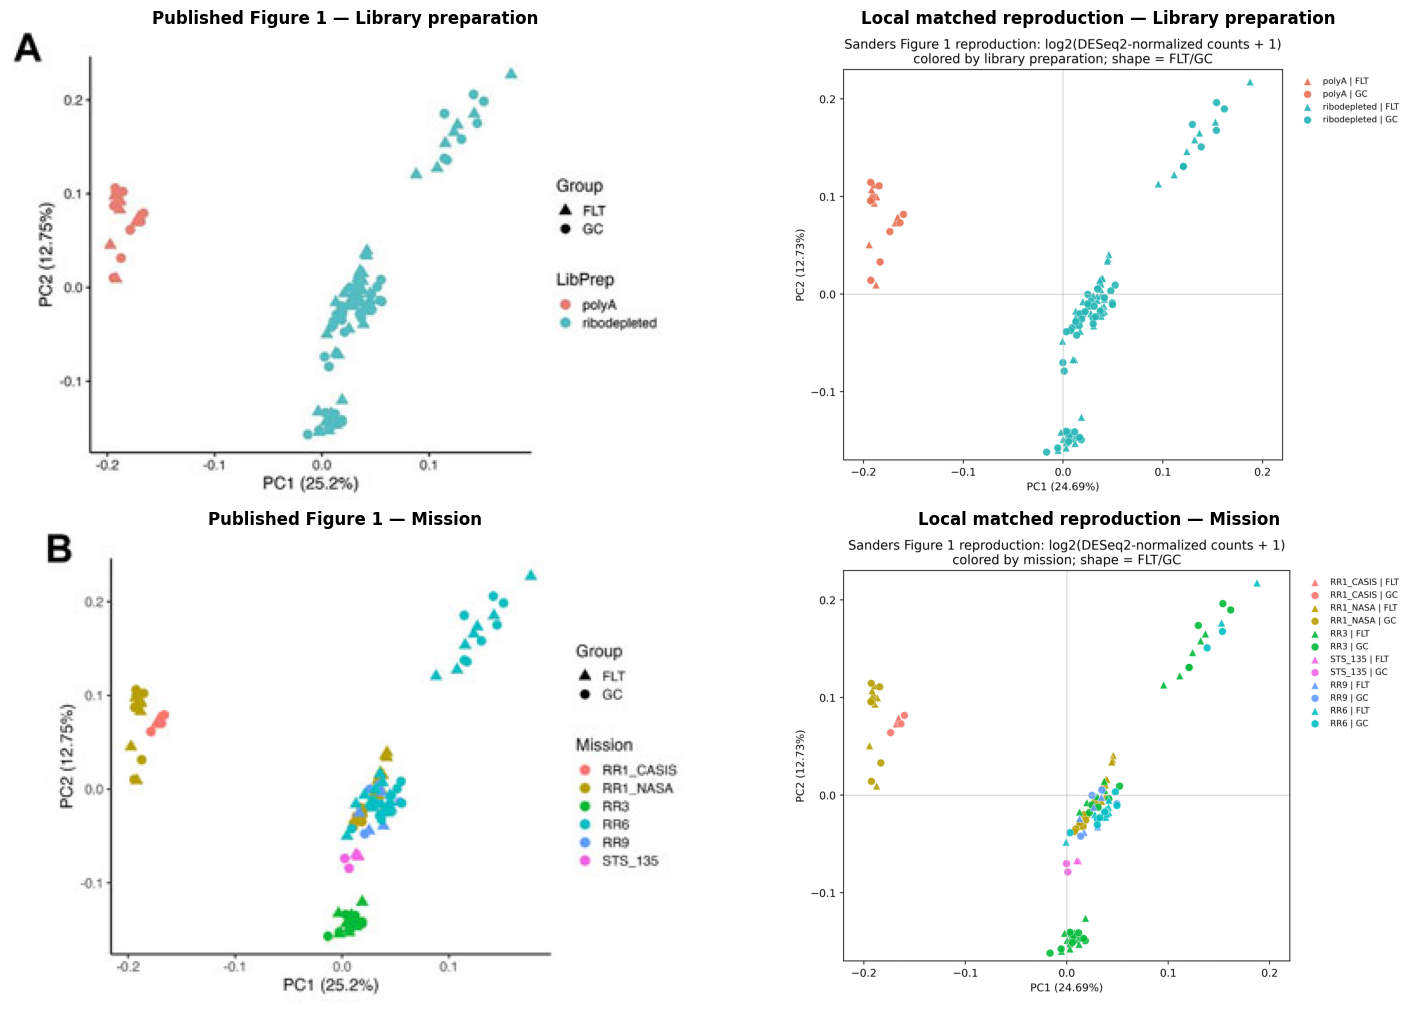

In [3]:
paper = mpimg.imread(HERE / 'references/Sanders_2023_Figure1.jpg')
local_lib = mpimg.imread(R / 'expression_figure1_library_preparation.png')
local_mission = mpimg.imread(R / 'expression_figure1_mission.png')
# The published source image contains panels A and B side by side.
cut = paper.shape[1] // 2
published_panels = [paper[:, :cut], paper[:, cut:]]
local_panels = [local_lib, local_mission]
row_names = ['Library preparation', 'Mission']
fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)
for row in range(2):
    axes[row, 0].imshow(published_panels[row])
    axes[row, 1].imshow(local_panels[row])
    axes[row, 0].set_title(f'Published Figure 1 — {row_names[row]}', fontweight='bold')
    axes[row, 1].set_title(f'Local matched reproduction — {row_names[row]}', fontweight='bold')
    axes[row, 0].axis('off')
    axes[row, 1].axis('off')
plt.show()

## 2. Exact sample cohort

In [4]:
print(f"Samples: {len(manifest)} | FLT: {(manifest.condition=='FLT').sum()} | GC: {(manifest.condition=='GC').sum()}")
display(cohort)
display(manifest.head())

Samples: 112 | FLT: 57 | GC: 55


,OSD,mission,library_preparation,condition,samples
0,OSD-137,RR3,ribodepleted,FLT,6
1,OSD-137,RR3,ribodepleted,GC,6
2,OSD-168,RR1_NASA,ribodepleted,FLT,10
3,OSD-168,RR1_NASA,ribodepleted,GC,10
4,OSD-168,RR3,ribodepleted,FLT,4
5,OSD-168,RR3,ribodepleted,GC,4
6,OSD-173,STS_135,ribodepleted,FLT,2
7,OSD-173,STS_135,ribodepleted,GC,2
8,OSD-242,RR9,ribodepleted,FLT,5
9,OSD-242,RR9,ribodepleted,GC,4


,sample_id,OSD,study_number,condition,mission,library_preparation,sequencing_facility,sequencing_parameters,preservation,strain,sex,age_at_launch,material,counts_file
0,Mmus_C57-6T_LVR_FLT_Rep1_F1,OSD-47,47,FLT,RR1_CASIS,polyA,UC Davis,SE 50bp 30M,Mini Cold Bag,C57BL/6NTac,Female,8 {month},Liver,data/osdr/raw/GLDS-47_rna_seq_RSEM_Unnormalize...
1,Mmus_C57-6T_LVR_FLT_Rep2_F2,OSD-47,47,FLT,RR1_CASIS,polyA,UC Davis,SE 50bp 30M,Mini Cold Bag,C57BL/6NTac,Female,8 {month},Liver,data/osdr/raw/GLDS-47_rna_seq_RSEM_Unnormalize...
2,Mmus_C57-6T_LVR_FLT_Rep3_F4,OSD-47,47,FLT,RR1_CASIS,polyA,UC Davis,SE 50bp 30M,Mini Cold Bag,C57BL/6NTac,Female,8 {month},Liver,data/osdr/raw/GLDS-47_rna_seq_RSEM_Unnormalize...
3,Mmus_C57-6T_LVR_GC_Rep1_G2,OSD-47,47,GC,RR1_CASIS,polyA,UC Davis,SE 50bp 30M,Mini Cold Bag,C57BL/6NTac,Female,8 {month},Liver,data/osdr/raw/GLDS-47_rna_seq_RSEM_Unnormalize...
4,Mmus_C57-6T_LVR_GC_Rep2_G3,OSD-47,47,GC,RR1_CASIS,polyA,UC Davis,SE 50bp 30M,Mini Cold Bag,C57BL/6NTac,Female,8 {month},Liver,data/osdr/raw/GLDS-47_rna_seq_RSEM_Unnormalize...


## 3. Figure 1 reproduction from expression

### Processing used for the right-hand panels

1. Select the same 112 mouse-liver samples from the seven OSDR studies: 57 flight and 55 ground controls.
2. Use the corrected primary unnormalized count tables and inner-join version-stripped Ensembl gene IDs across studies.
3. Apply the DESeq2 median-of-ratios size-factor procedure across the combined matrix.
4. Apply `log2(normalized count + 1)` before PCA. This step is inferred because it nearly reproduces the published PC fractions; it is not explicitly stated in the article.
5. Run centered, unscaled PCA, corresponding to R `prcomp(center=TRUE, scale.=FALSE)`.
6. Plot the same samples by library preparation or mission, with flight/ground encoded by marker shape.

No batch correction, gene-wise z-scoring, or supervised adjustment is performed.

**Matched display convention.** The saved statistical PCA coordinates remain native sample scores. For the reproduction plots only, each displayed component-score vector is divided by its Euclidean norm, matching the paper's approximately ±0.2 coordinate scale. PC2 is multiplied by −1 to resolve PCA's arbitrary sign in the same orientation as Figure 1. The axis limits and ticks match the published panel. These display-only operations preserve relative sample geometry and variance explained.

In [5]:
variance_compare = pd.DataFrame({
    'analysis':['Published Figure 1','Local matched reproduction','Frozen BridgeRNA'],
    'PC1':[0.252,expr_var.variance_explained.iloc[0],fm_var.variance_explained.iloc[0]],
    'PC2':[0.1275,expr_var.variance_explained.iloc[1],fm_var.variance_explained.iloc[1]]})
display(variance_compare.style.format({'PC1':'{:.2%}','PC2':'{:.2%}'}))

,analysis,PC1,PC2
0,Published Figure 1,25.20%,12.75%
1,Local matched reproduction,24.69%,12.73%
2,Frozen BridgeRNA,87.38%,5.99%


### Direct expression UMAP

UMAP is run deterministically and directly on the complete corrected `log2(DESeq2-normalized counts + 1)` gene-expression matrix; PCA coordinates are not used as input. It is descriptive and nonlinear: distances and axis orientation should not be interpreted as variance explained. Panels are colored by the two principal reported batch variables; flight/ground remains encoded by marker shape.

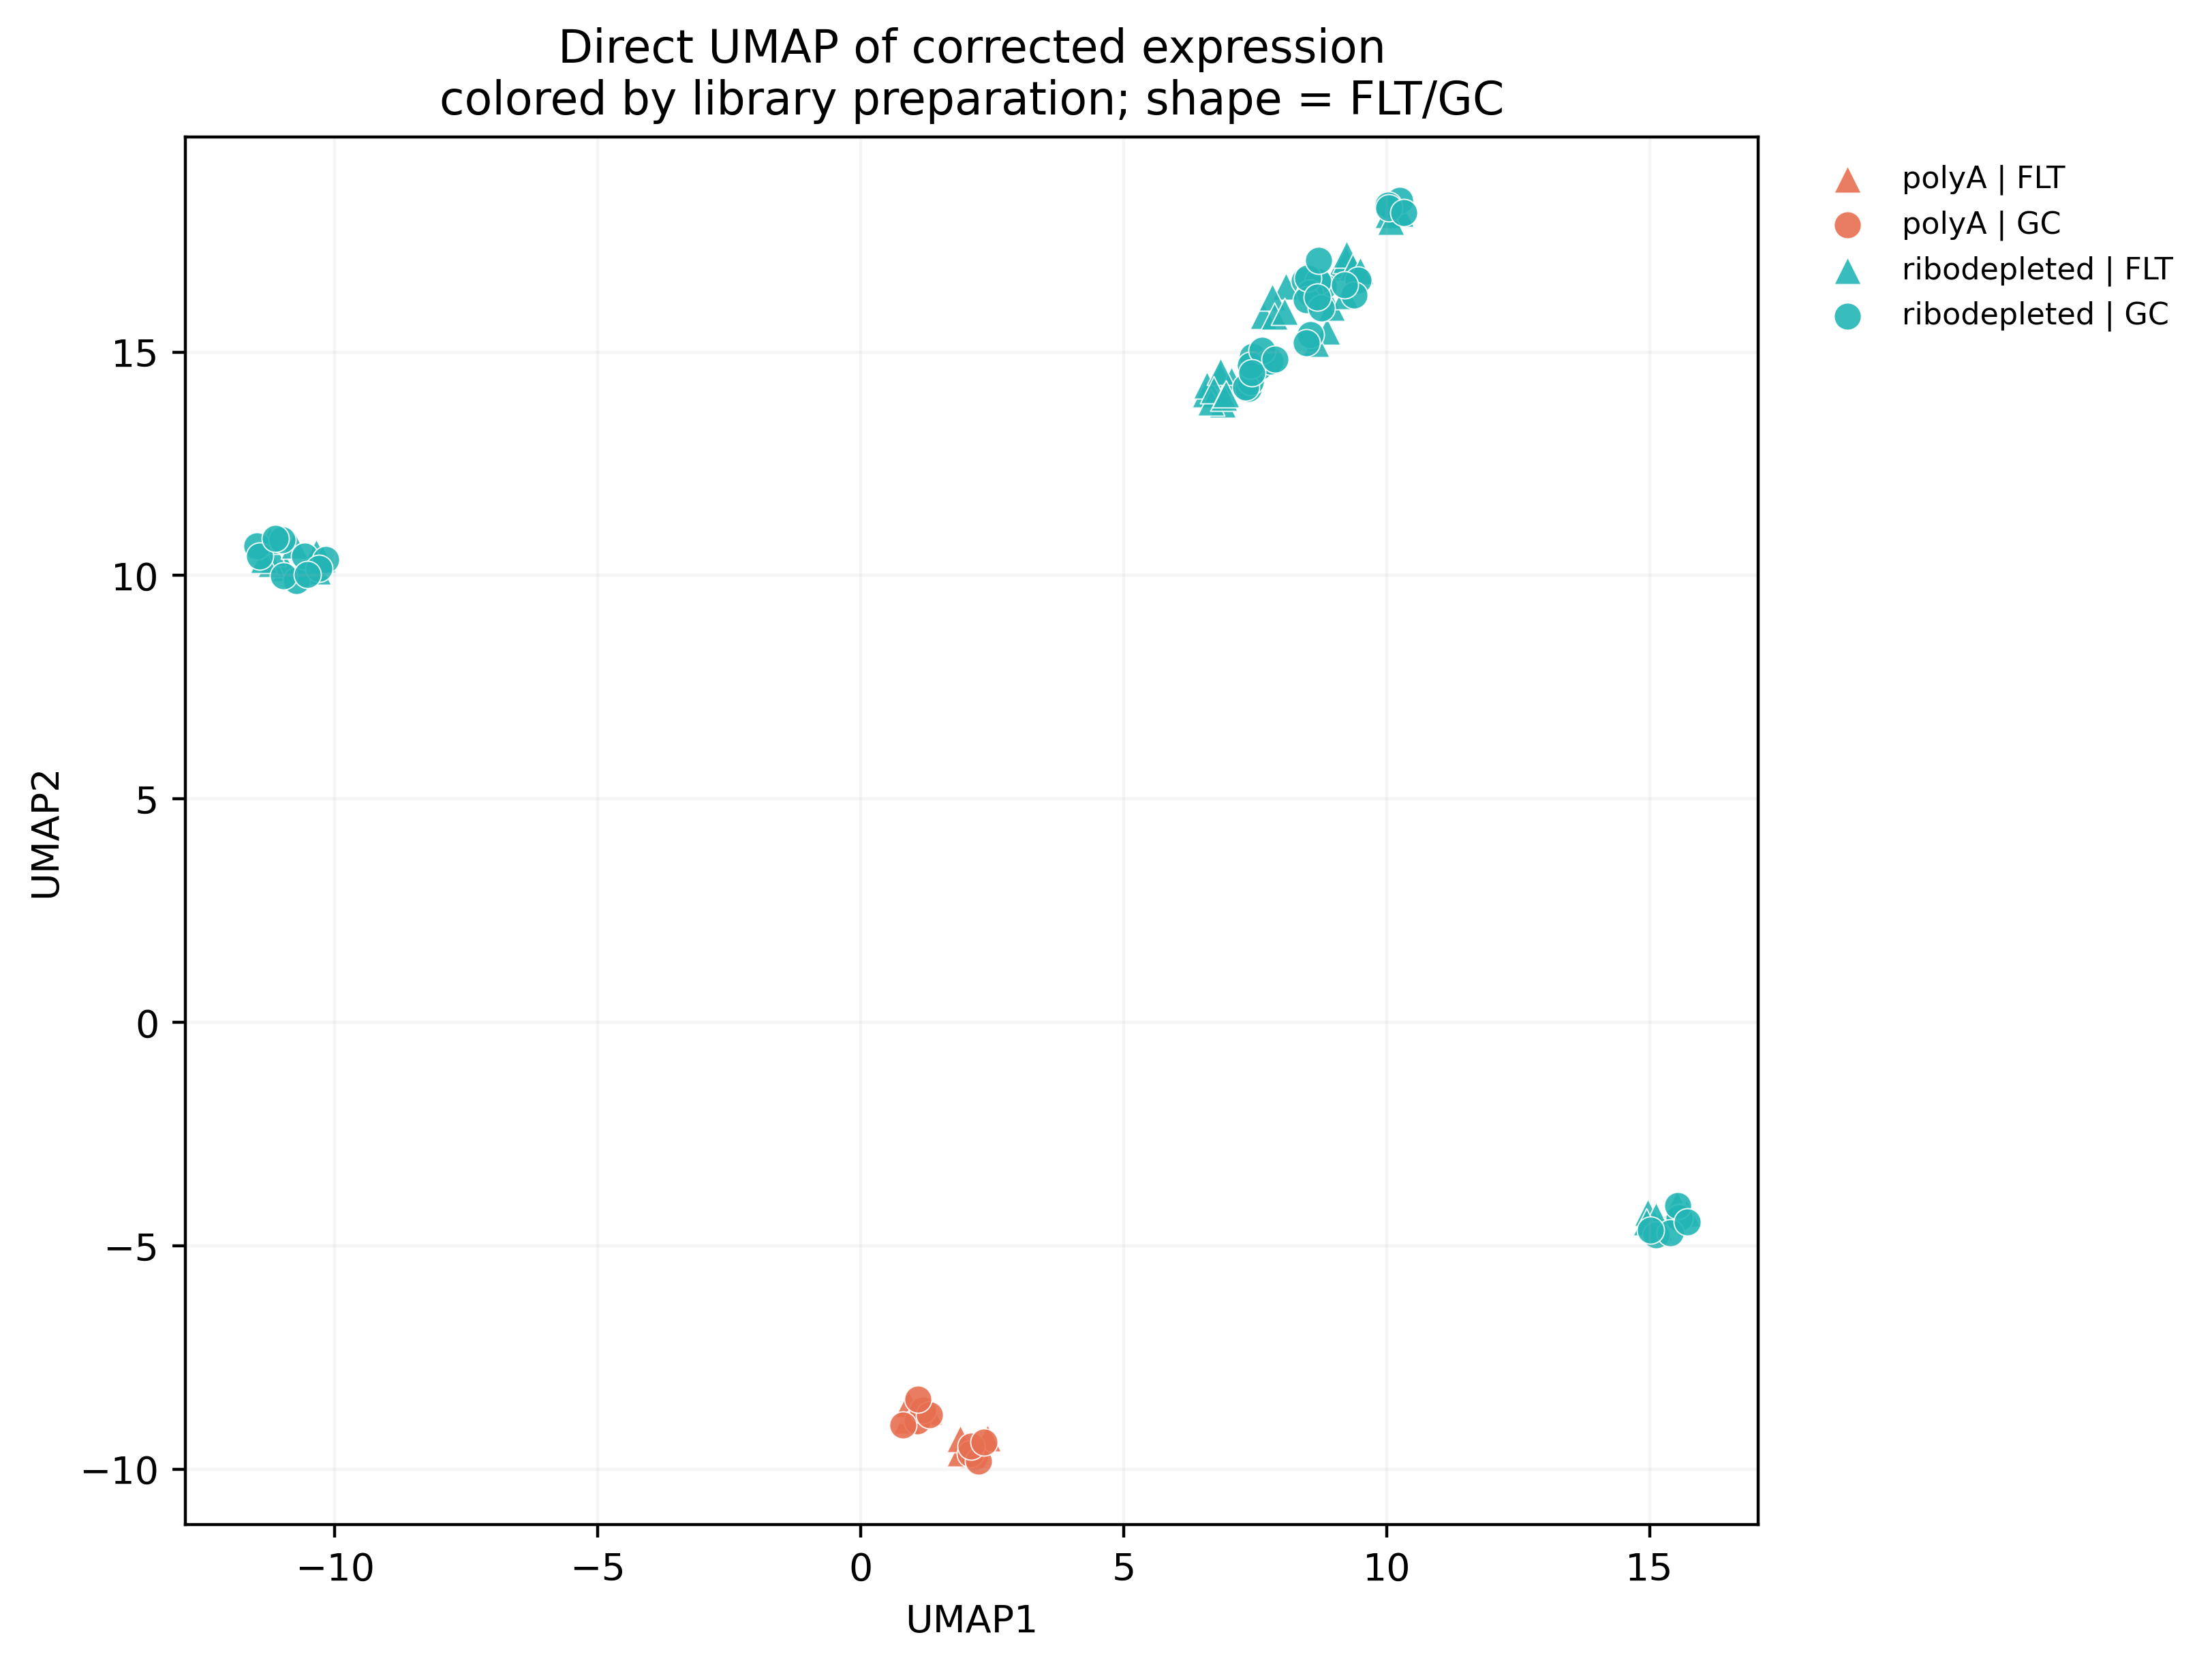

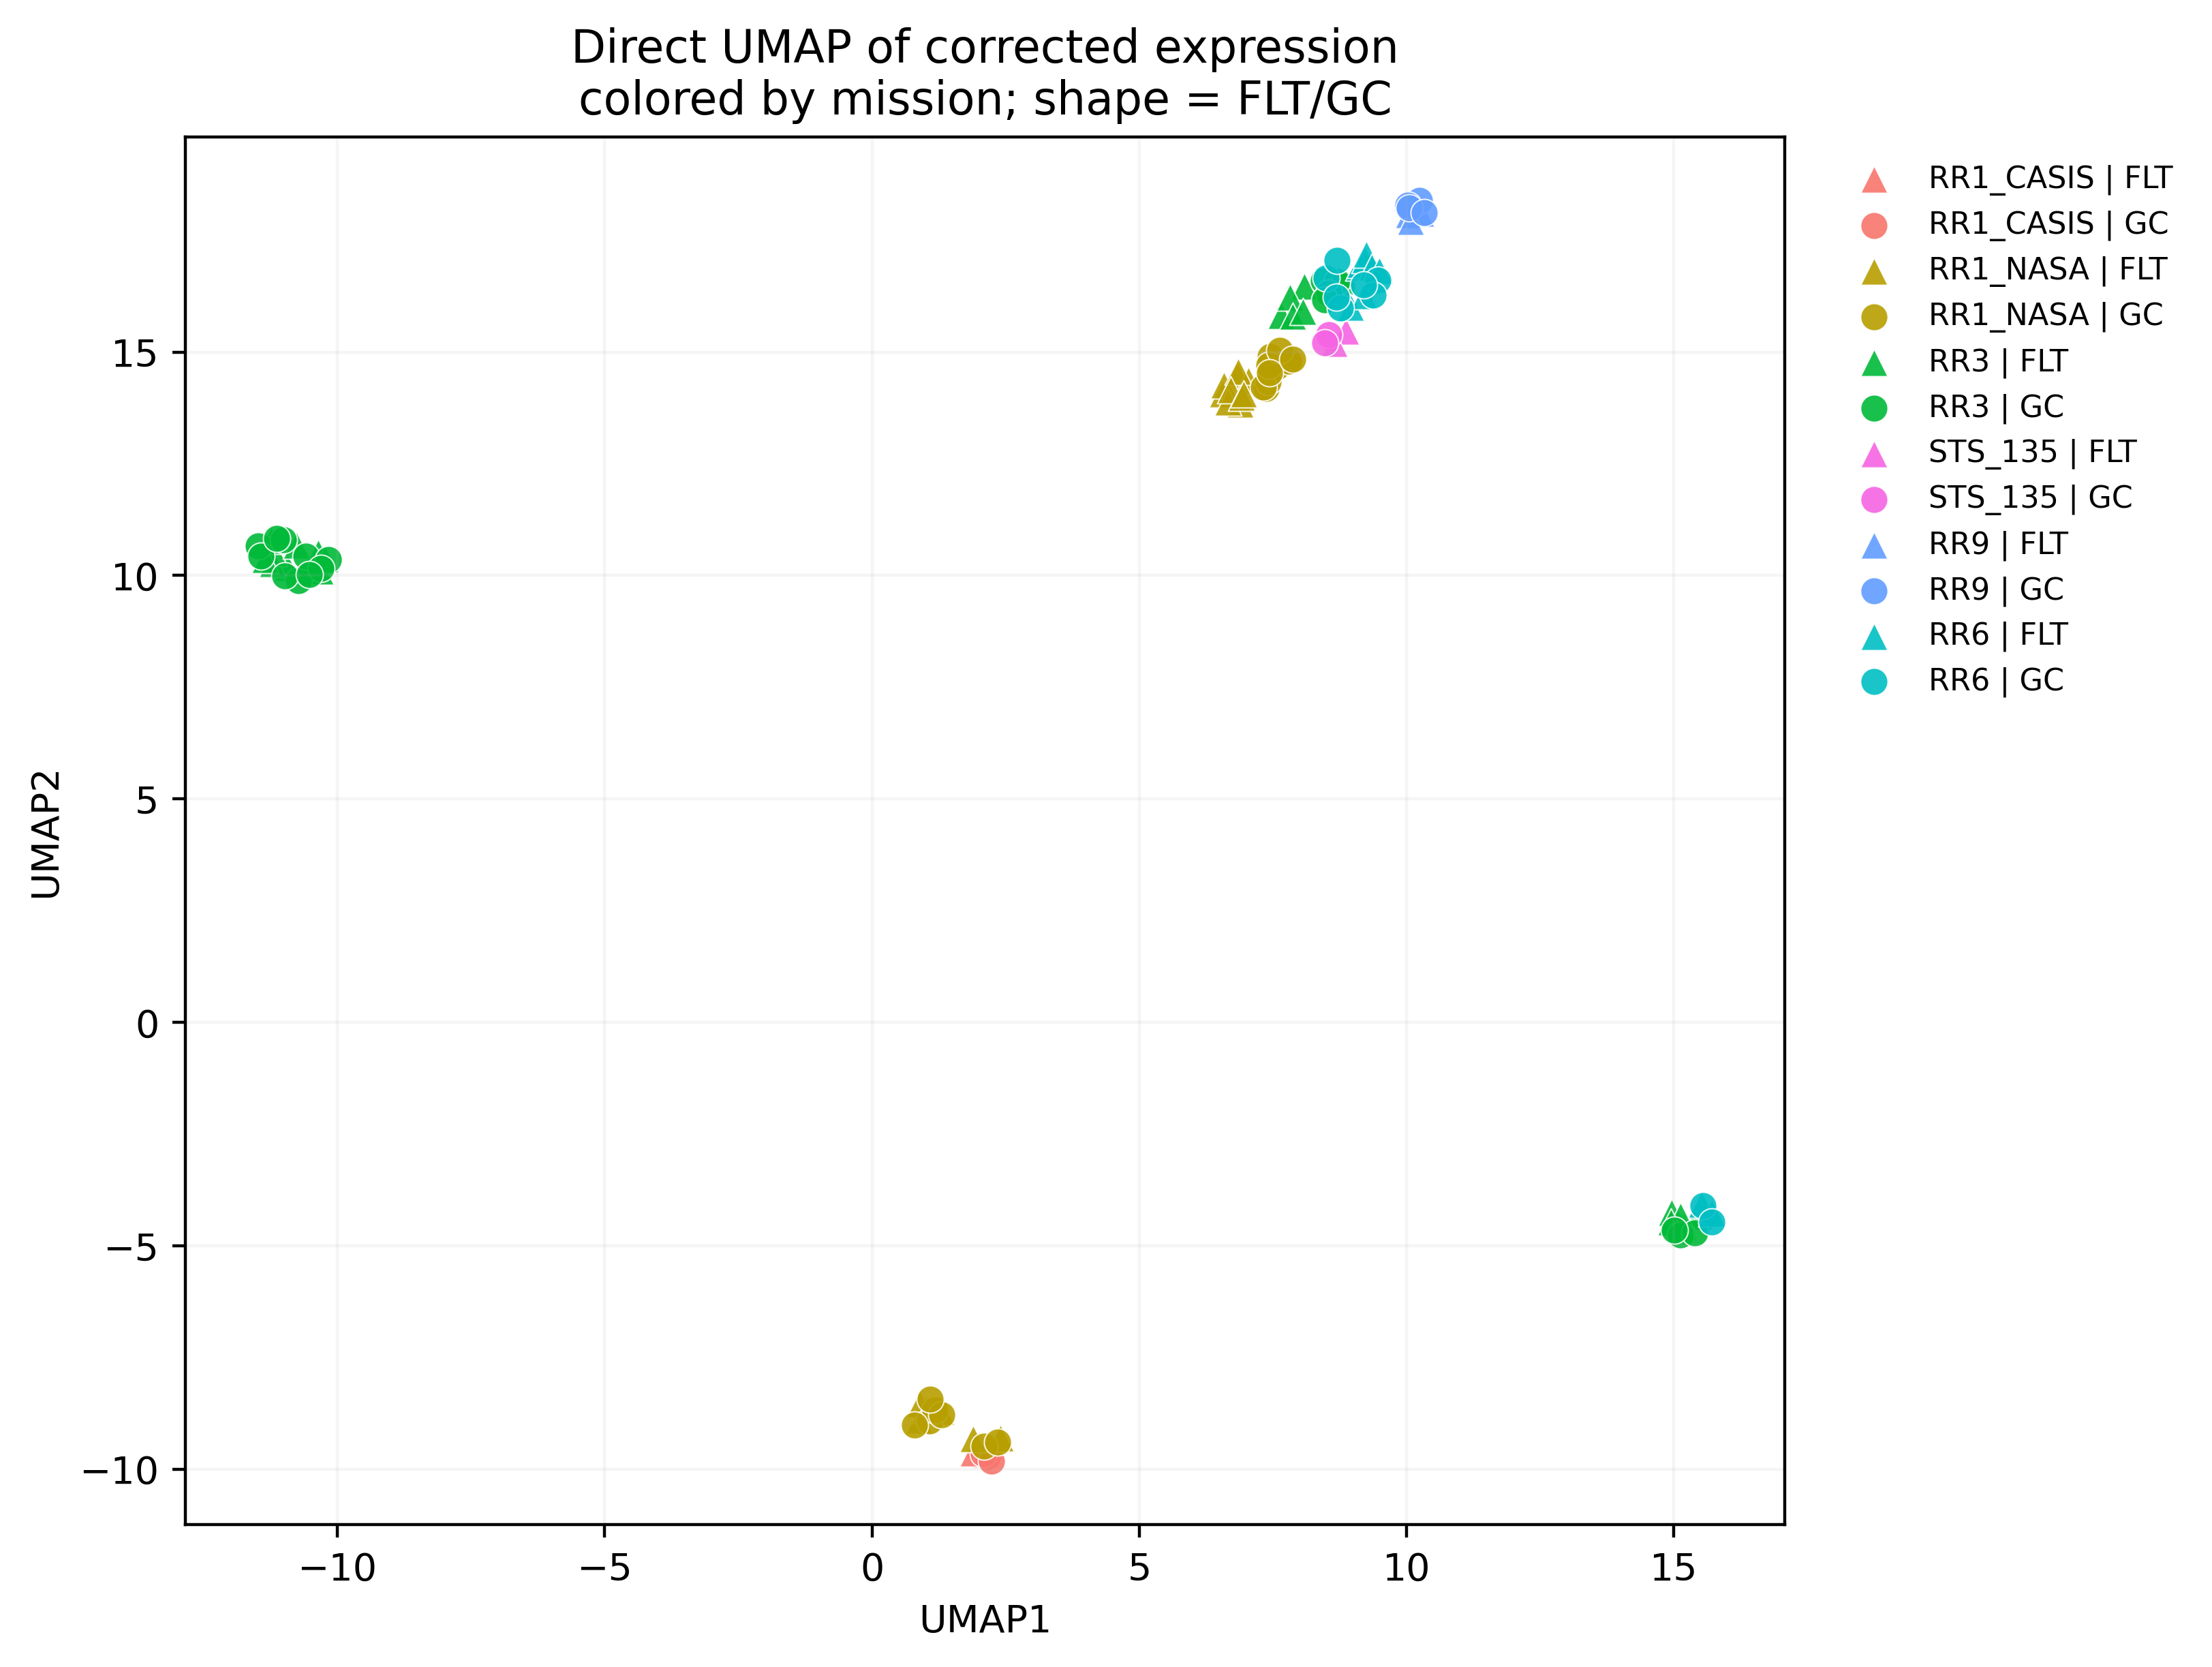

In [6]:
display(Image(filename=str(R / 'expression_umap_library_preparation.png')))
display(Image(filename=str(R / 'expression_umap_mission.png')))

## 4. The authors’ batch-corrected example

Sanders et al. next corrected the **combined multi-study expression matrix** by supplying either library preparation or mission as the batch variable. Their Figure 2 shows four representative results:

- **A:** ComBat correction for library preparation
- **B:** ComBat-seq correction for library preparation
- **C:** ComBat correction for mission
- **D:** ComBat-seq correction for mission

They used ComBat and ComBat-seq from the `sva` R package, applied correction to the combined DESeq2-normalized dataset using sample metadata to define the chosen batch, and then reran PCA to assess whether technical groups moved closer while flight and ground samples remained distinguishable. They also evaluated MBatch ANOVA, Empirical Bayes, and Median Polish elsewhere in the paper; Figure 2 is an illustrative subset, not evidence that one method universally won every evaluation criterion.

This corrected figure is included only as context. **We do not apply any of these corrections to BridgeRNA**, because the benchmark asks whether its frozen representation naturally retains, reduces, or reorganizes the reported structure.

**Mission colors are fixed to the paper's ggplot palette throughout this notebook:** RR1_CASIS `#F8766D`, RR1_NASA `#B79F00`, RR3 `#00BA38`, RR6 `#00BFC4`, RR9 `#619CFF`, and STS_135 `#F564E3`. The same mapping is used in expression, BridgeRNA, UMAP, and all correction/recoloring figures.

### Published Figure 2 — complete four-panel grid

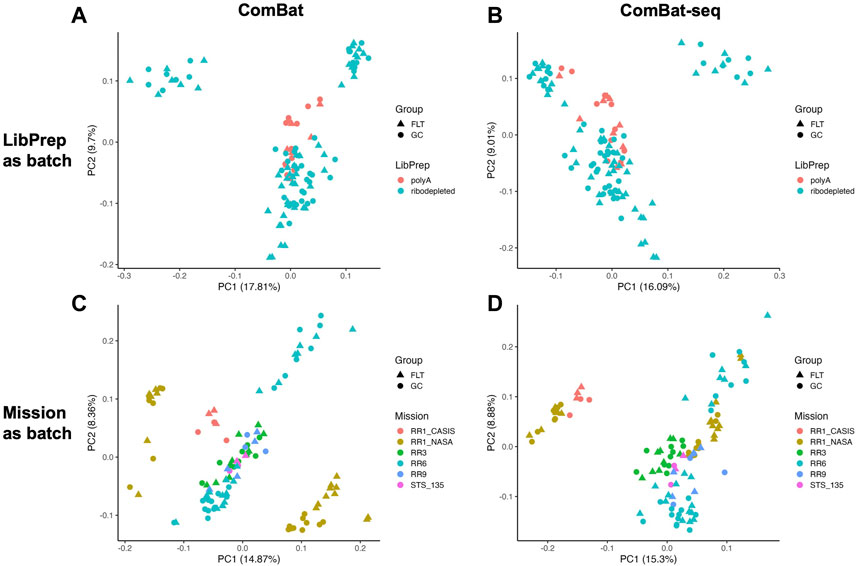

In [7]:
display(Image(filename=str(HERE / 'references/Sanders_2023_Figure2_corrected.jpg')))

### Local Figure 2 reproduction — published coloring

This is our reproduced ComBat/ComBat-seq four-panel grid using the **same color variable and mission palette as the published Figure 2**. It provides the direct method-for-method reproduction before any complementary recoloring.

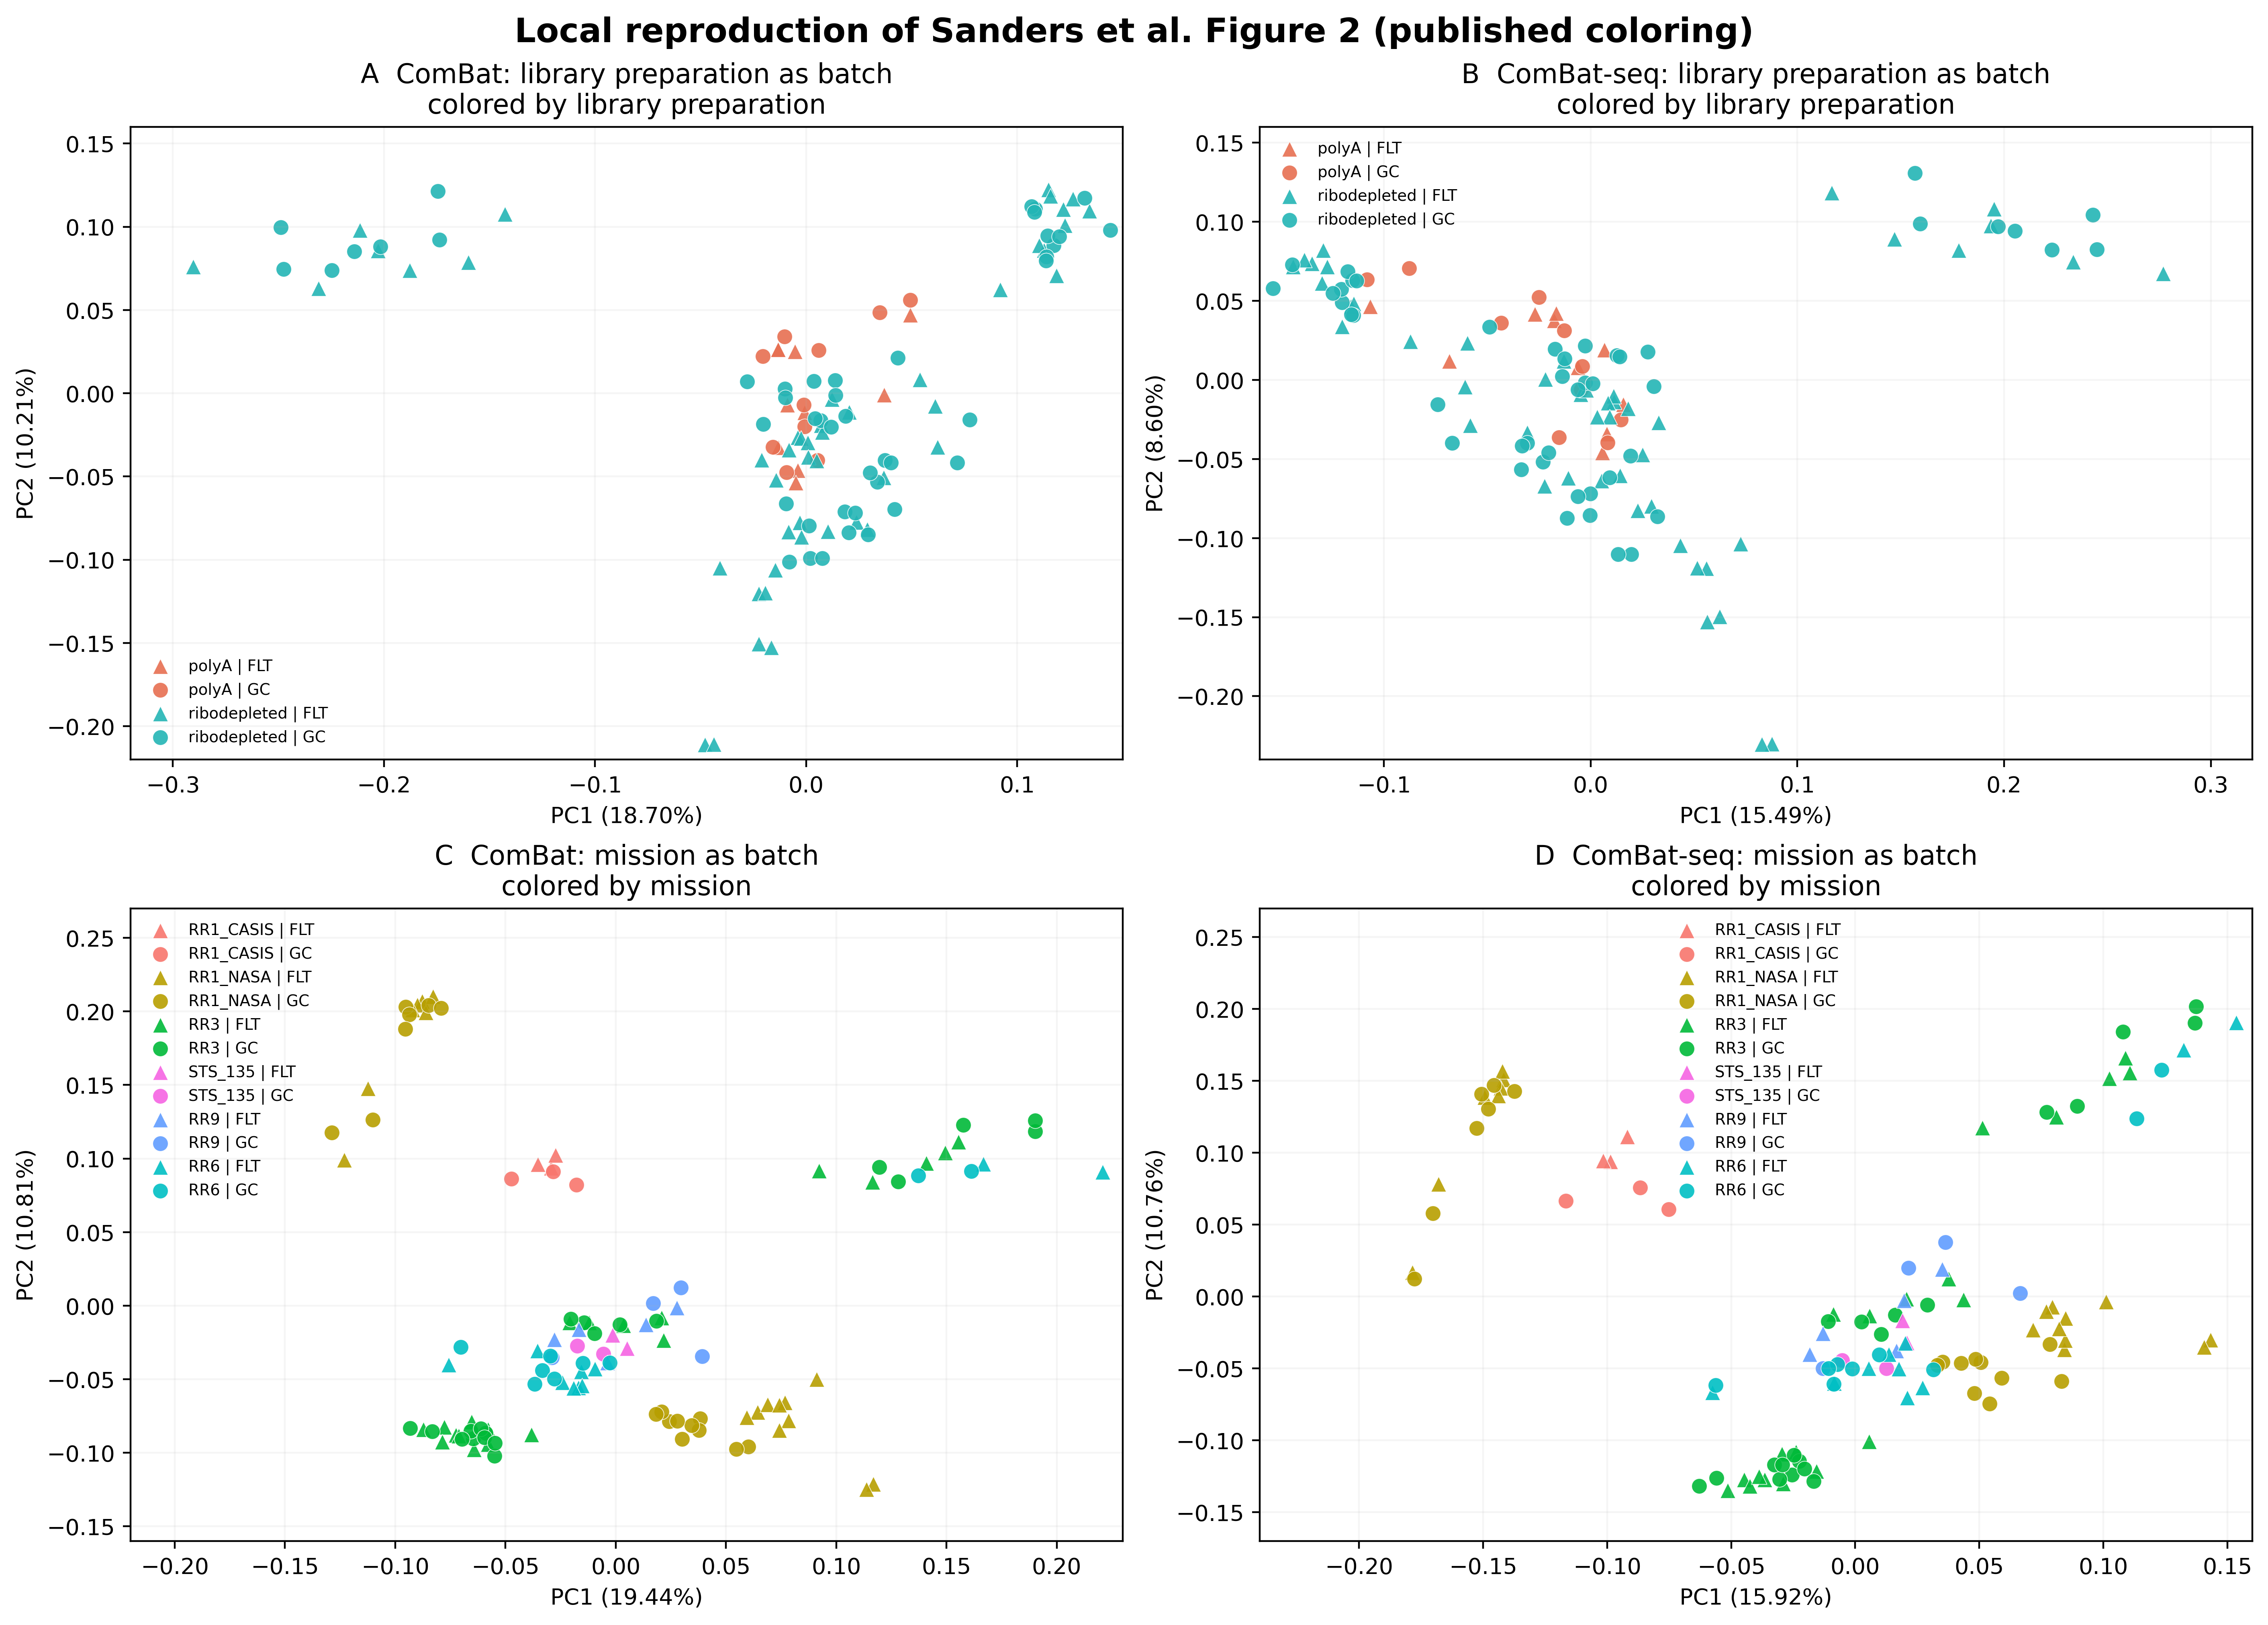

In [8]:
display(Image(filename=str(R / 'combat_four_panel_reproduction.png')))

### Full four-panel grid with the coloring switched

This grid uses our reproduced ComBat/ComBat-seq coordinates, but deliberately colors by the **other** technical variable:

- Library-preparation-corrected panels are colored by mission.
- Mission-corrected panels are colored by library preparation.
- Marker shape remains FLT versus GC.

The coordinates, correction models, and PCA are unchanged. Only the coloring changes, allowing residual organization by the complementary batch variable to become visible.

For visual comparability, both our published-color and switched-color reproductions use unit-normalized component-score vectors, the published axis limits, and the published orientation. These are display-only transformations; saved native PCA coordinates and explained-variance calculations are unchanged.

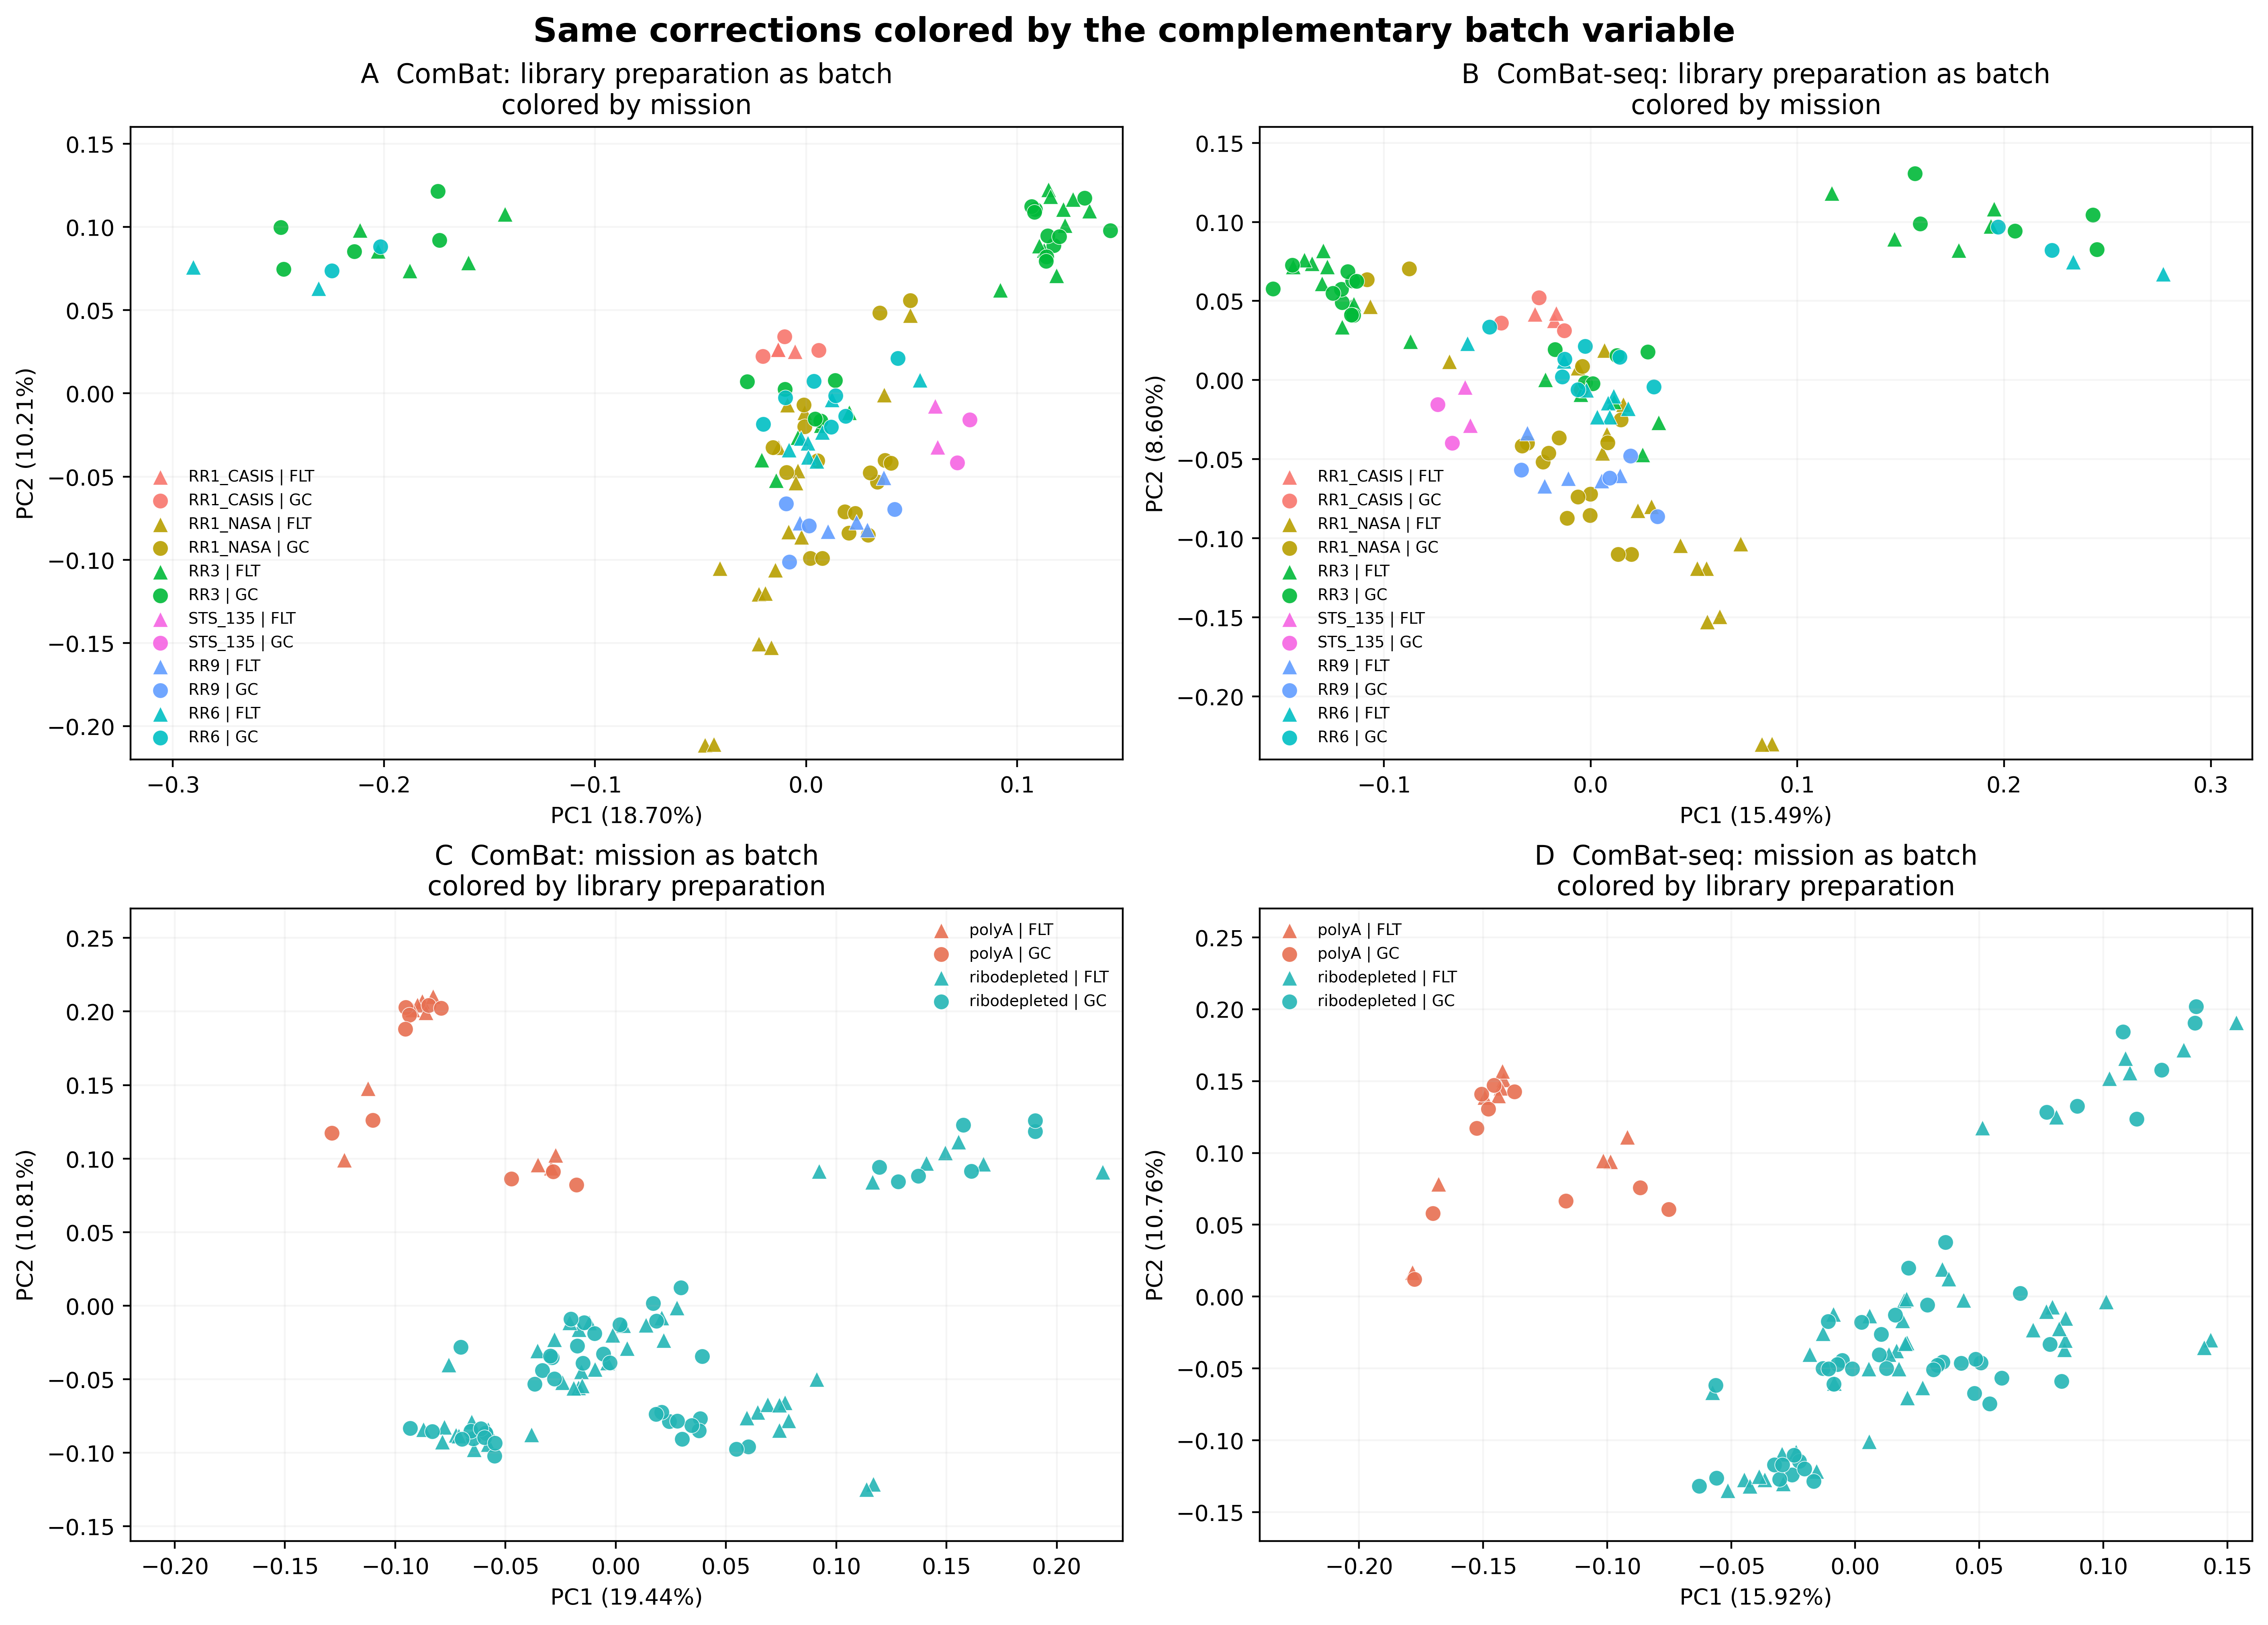

In [9]:
display(Image(filename=str(R / 'combat_four_panel_complementary_coloring.png')))

In [10]:
combat_var = pd.read_csv(R / 'combat_pca_variance.csv')
published_corrected = {
    ('library_preparation', 'ComBat'): (0.1781, 0.0970),
    ('library_preparation', 'ComBat-seq'): (0.1609, 0.0901),
    ('mission', 'ComBat'): (0.1487, 0.0836),
    ('mission', 'ComBat-seq'): (0.1530, 0.0898),
}
rows = []
for (batch, method), (paper_pc1, paper_pc2) in published_corrected.items():
    z = combat_var[(combat_var.batch_variable == batch) & (combat_var.method == method)].sort_values('PC')
    rows.append({'Batch variable': batch.replace('_', ' '), 'Method': method,
                 'Published PC1': paper_pc1, 'Local PC1': z.variance_explained.iloc[0],
                 'Published PC2': paper_pc2, 'Local PC2': z.variance_explained.iloc[1]})
display(pd.DataFrame(rows).style.format({c:'{:.2%}' for c in ['Published PC1','Local PC1','Published PC2','Local PC2']}).hide(axis='index'))

Batch variable,Method,Published PC1,Local PC1,Published PC2,Local PC2
library preparation,ComBat,17.81%,18.70%,9.70%,10.21%
library preparation,ComBat-seq,16.09%,15.49%,9.01%,8.60%
mission,ComBat,14.87%,19.44%,8.36%,10.81%
mission,ComBat-seq,15.30%,15.92%,8.98%,10.76%


### Direct published-versus-switched comparisons

Each image below contains two plots: the corresponding published Figure 2 panel on the left and our switched-color version of that same correction on the right. These comparisons isolate what the complementary coloring reveals without compressing all comparisons into one image.

#### Panel A: ComBat — library preparation as batch

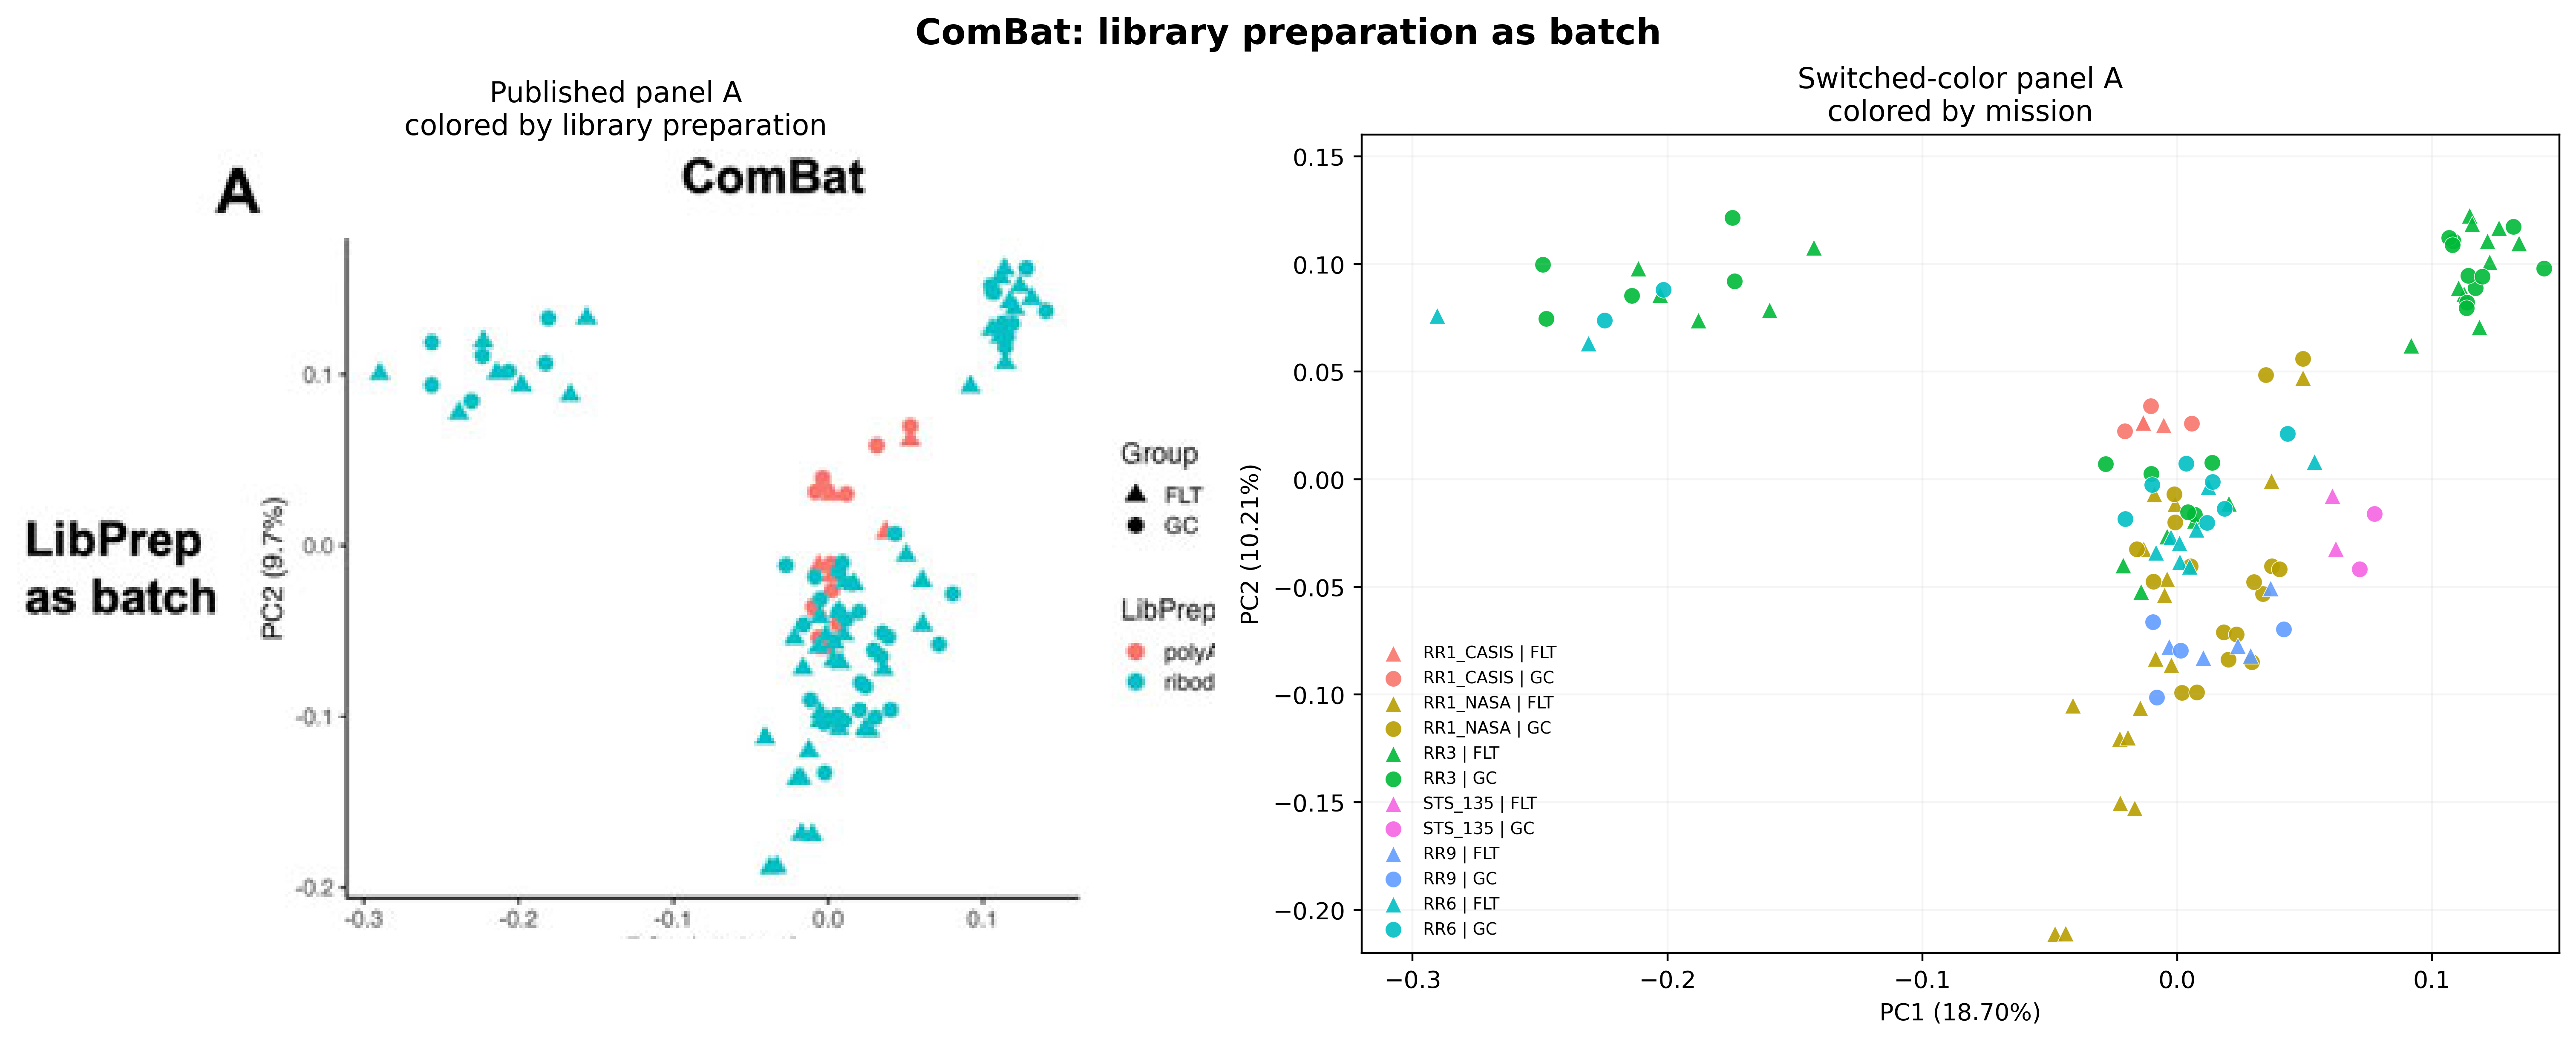

In [11]:
display(Image(filename=str(R / 'combat_published_vs_switched_panel_A.png')))

#### Panel B: ComBat-seq — library preparation as batch

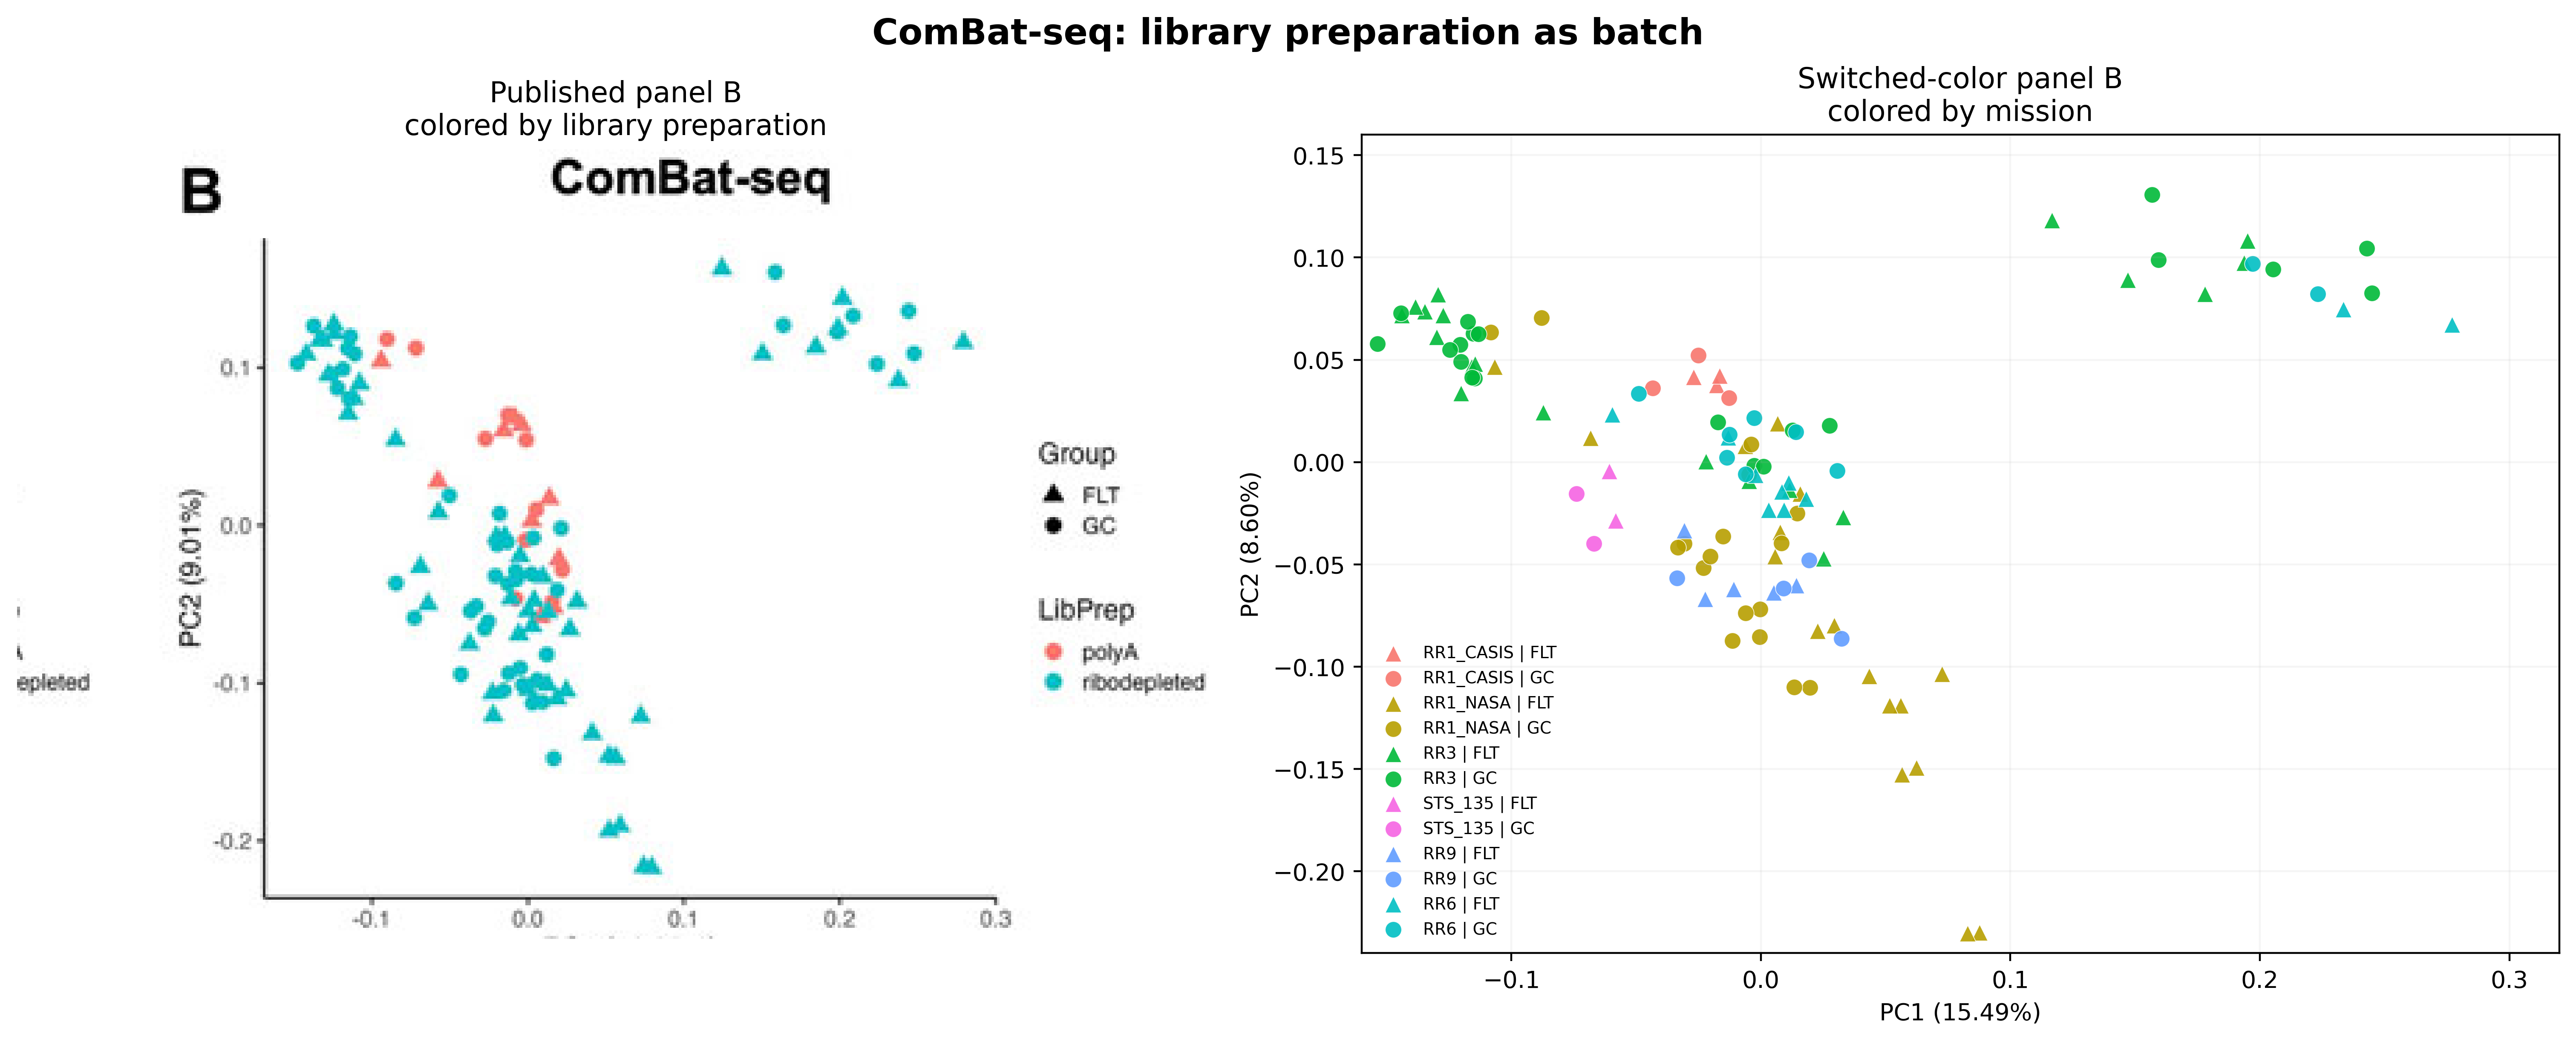

In [12]:
display(Image(filename=str(R / 'combat_published_vs_switched_panel_B.png')))

#### Panel C: ComBat — mission as batch

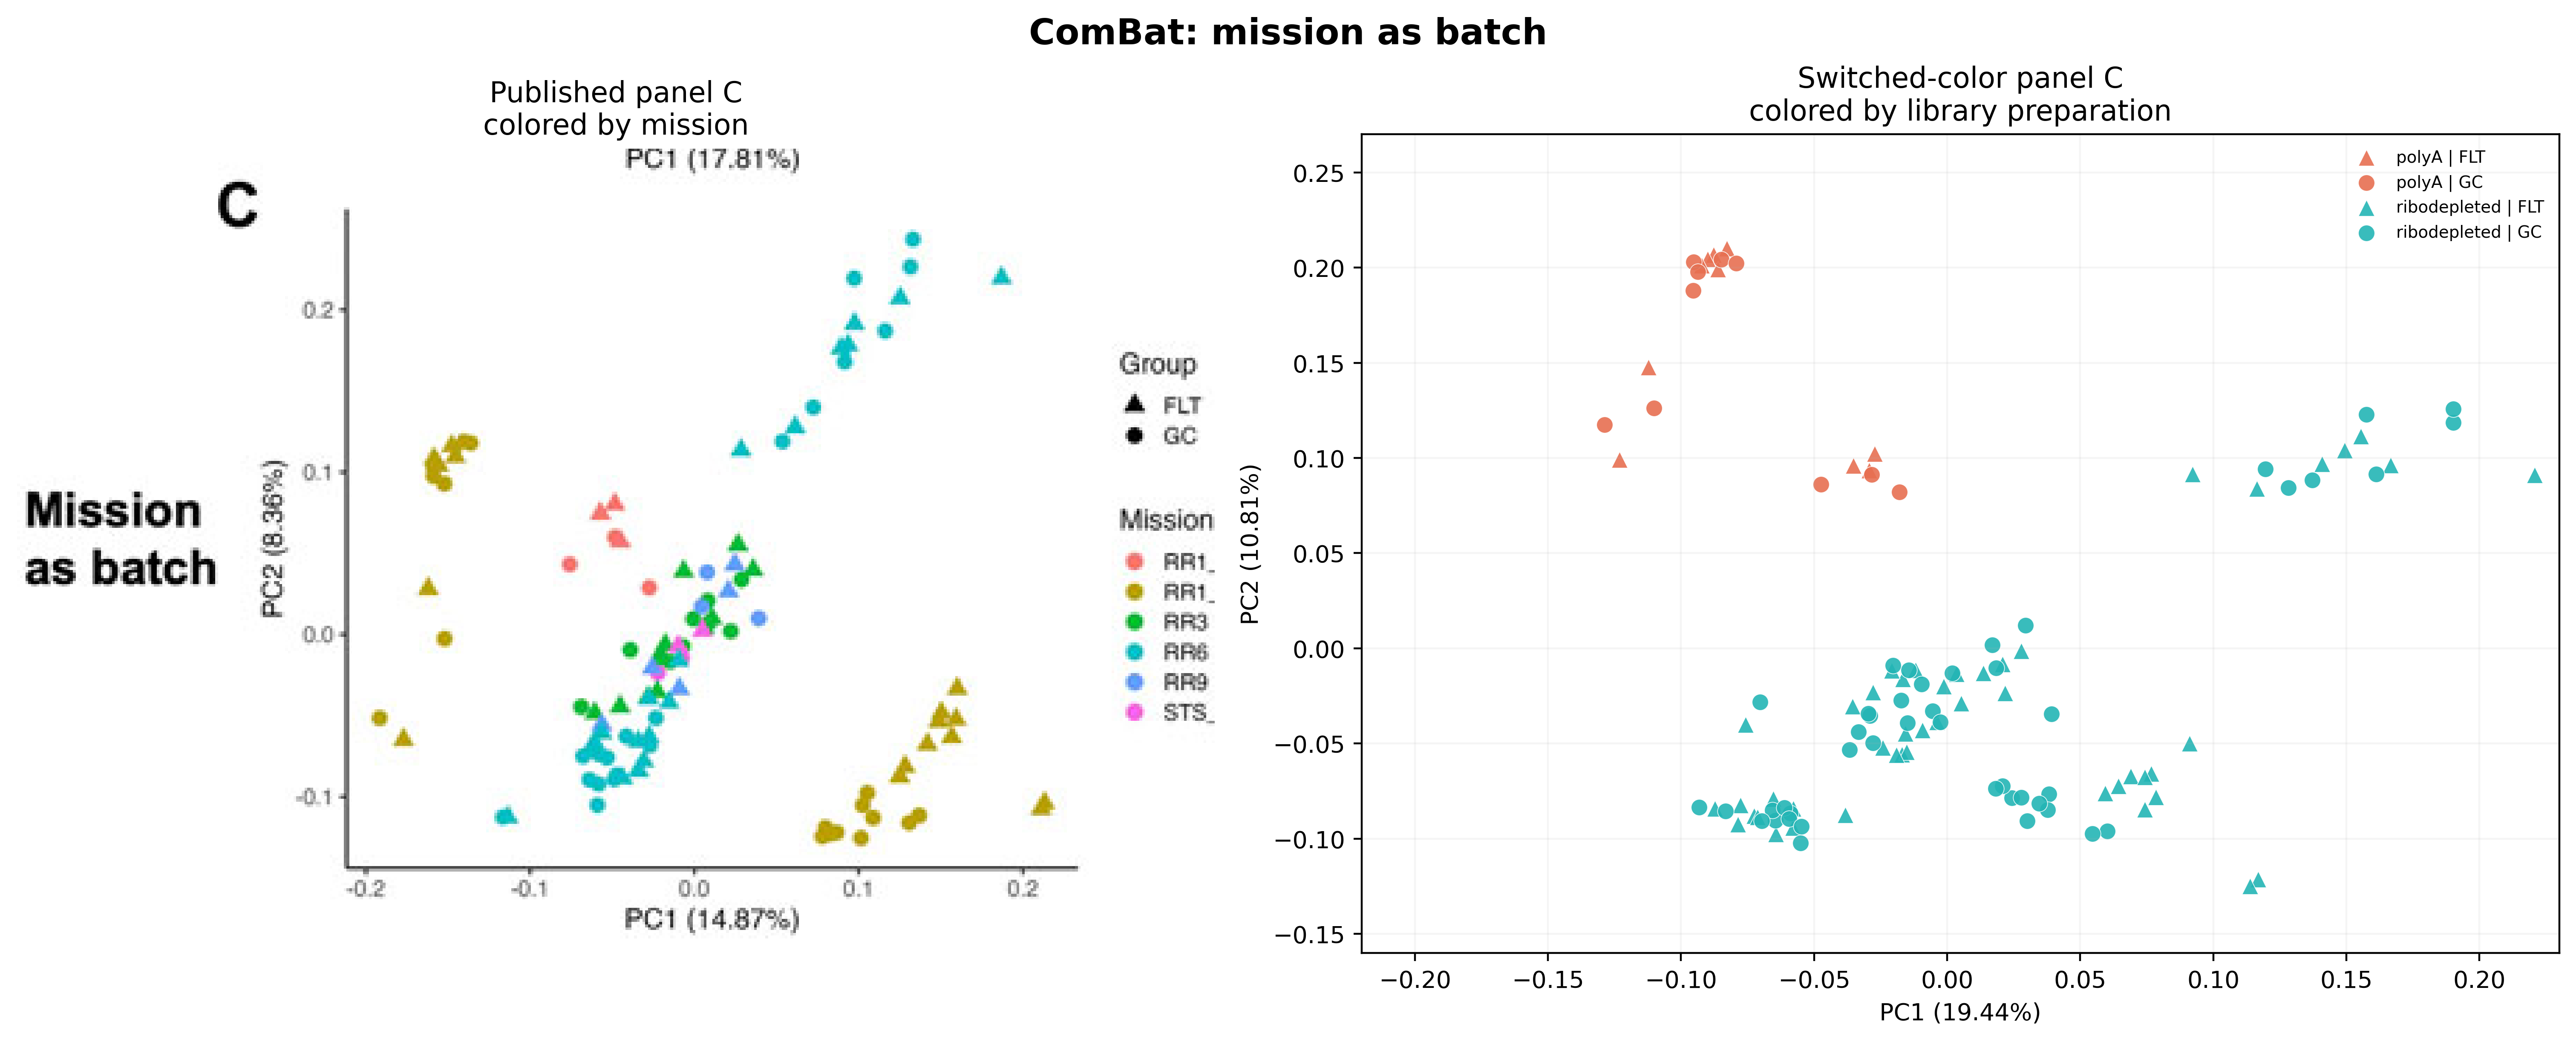

In [13]:
display(Image(filename=str(R / 'combat_published_vs_switched_panel_C.png')))

#### Panel D: ComBat-seq — mission as batch

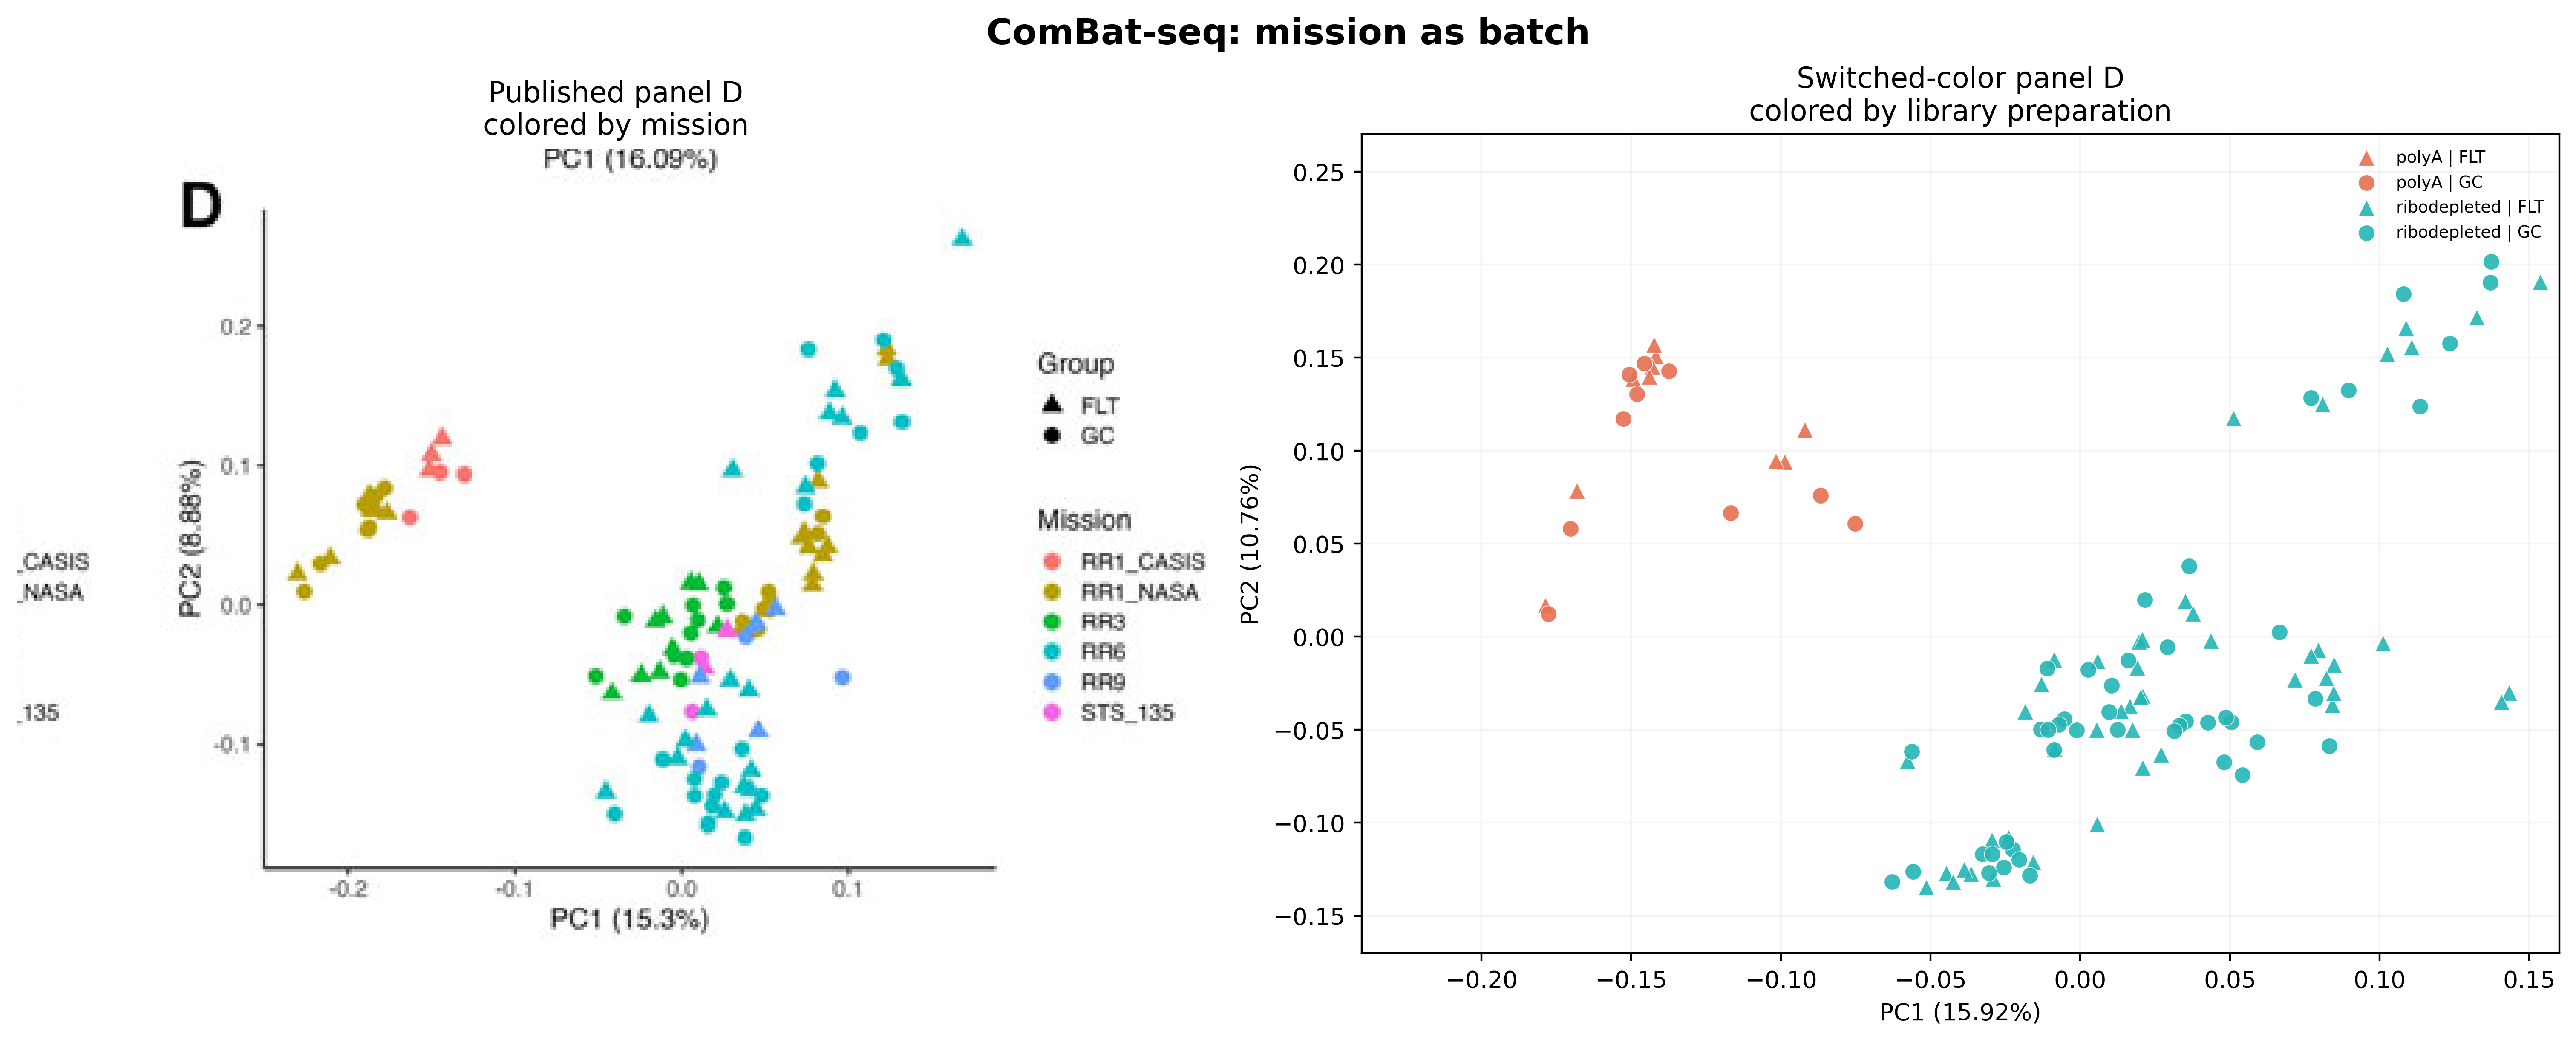

In [14]:
display(Image(filename=str(R / 'combat_published_vs_switched_panel_D.png')))

## 5. Matched frozen BridgeRNA representation

For the same 112 samples, raw counts are converted to TPM with mouse gene lengths, mapped into the exact 15,165-gene vocabulary, transformed by natural `log1p`, and encoded by the frozen 45.6M checkpoint. PCA is then applied to the resulting 512-D sample embeddings. No labels enter inference or PCA.

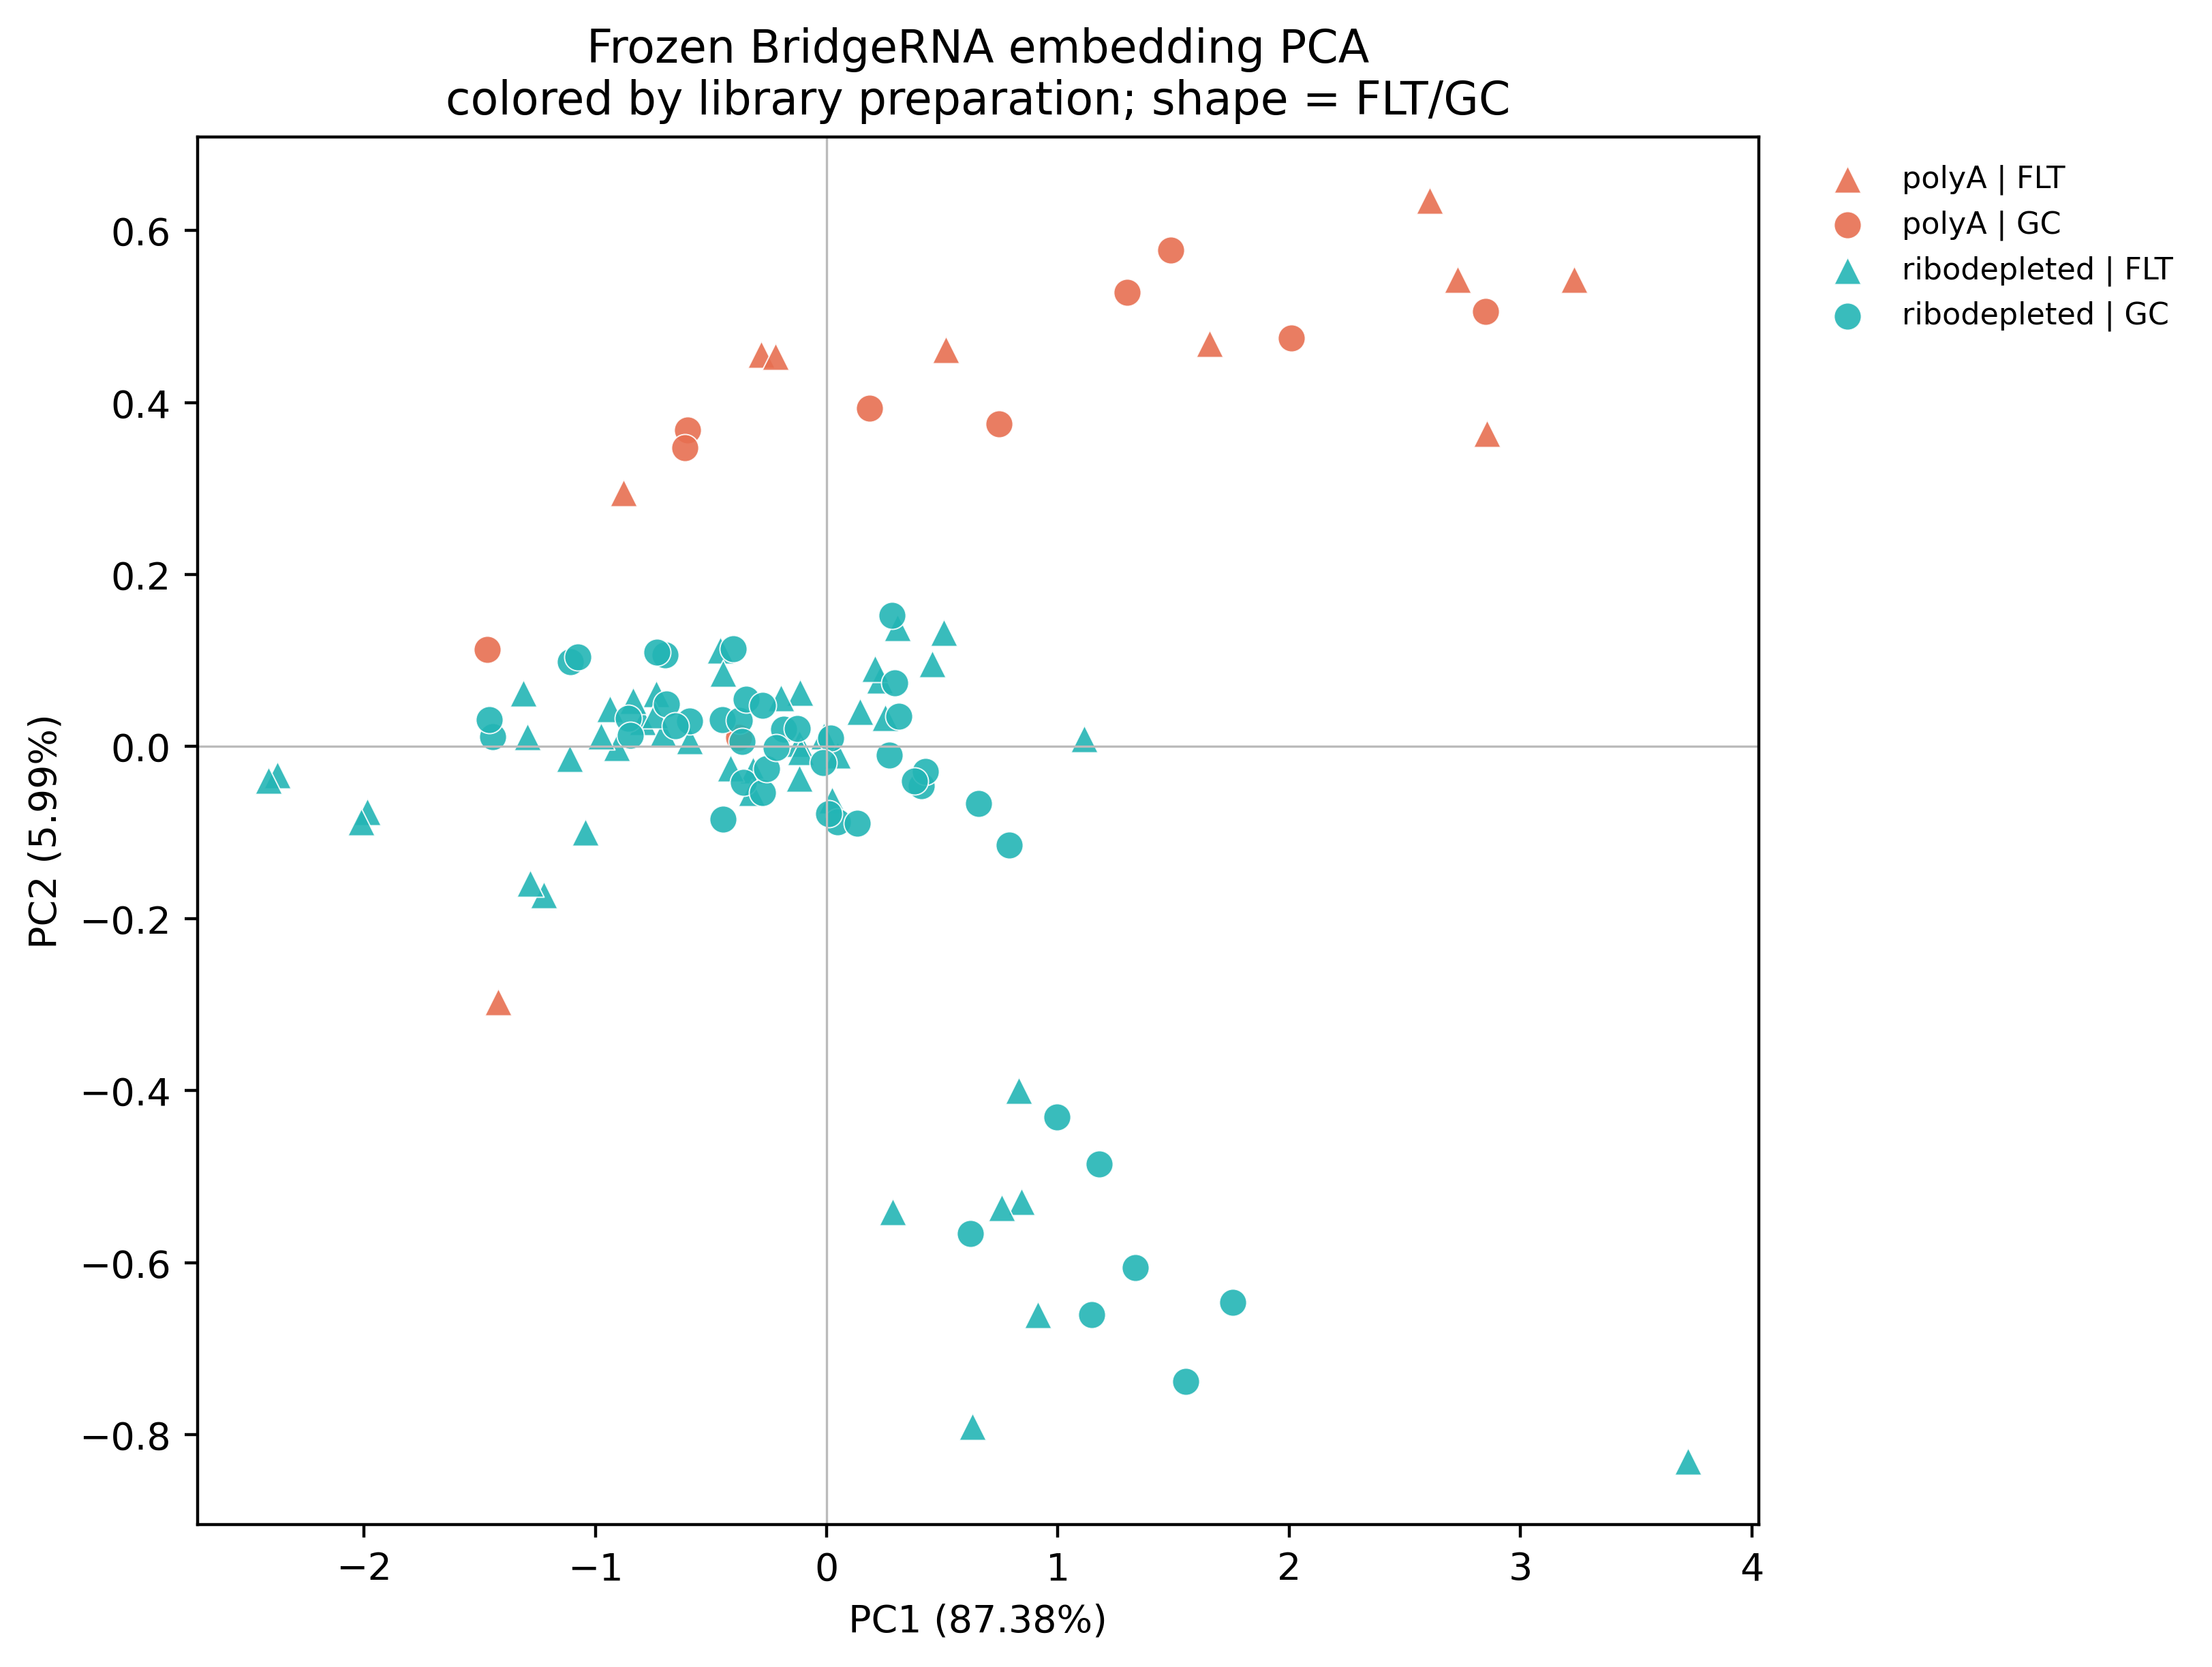

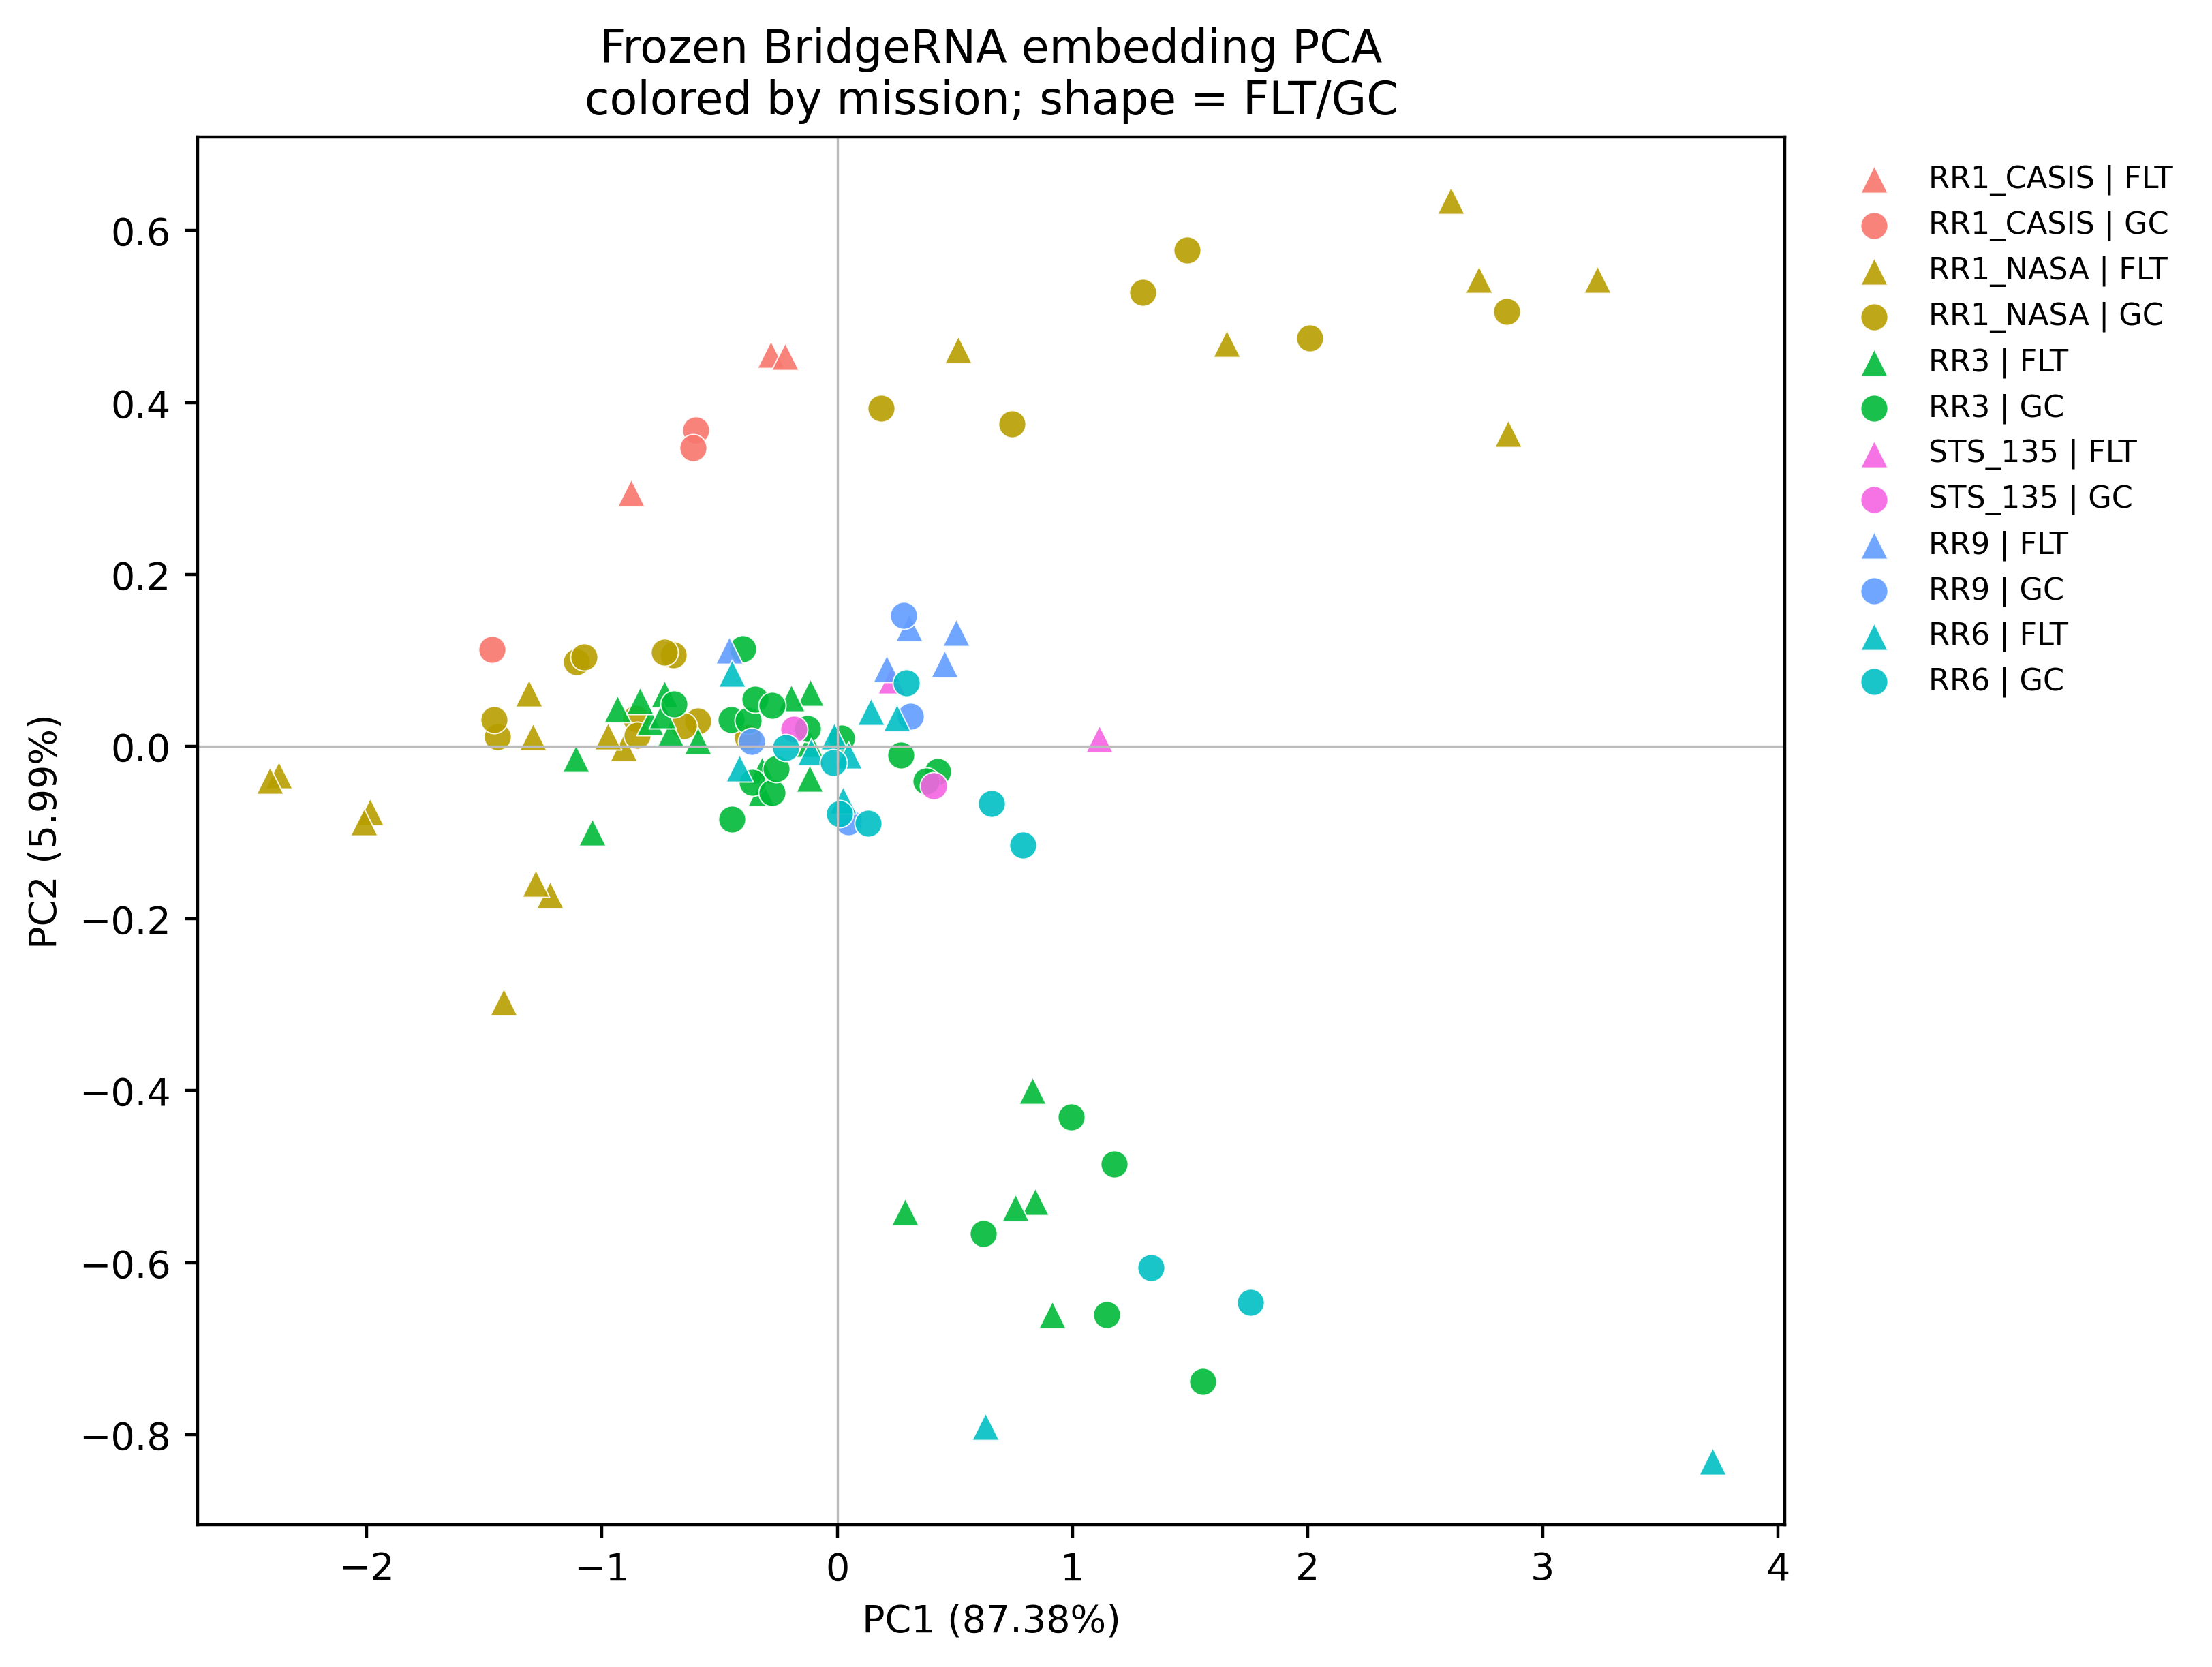

In [15]:
display(Image(filename=str(R / 'bridgerna_figure1_library_preparation.png')))
display(Image(filename=str(R / 'bridgerna_figure1_mission.png')))

### Direct frozen BridgeRNA UMAP

For a matched nonlinear view, UMAP is applied directly to the frozen 512-D BridgeRNA embeddings with identical UMAP settings and seed; PCA coordinates are not used as input. These coordinates are visualization-only and are not used in the categorical R² analysis.

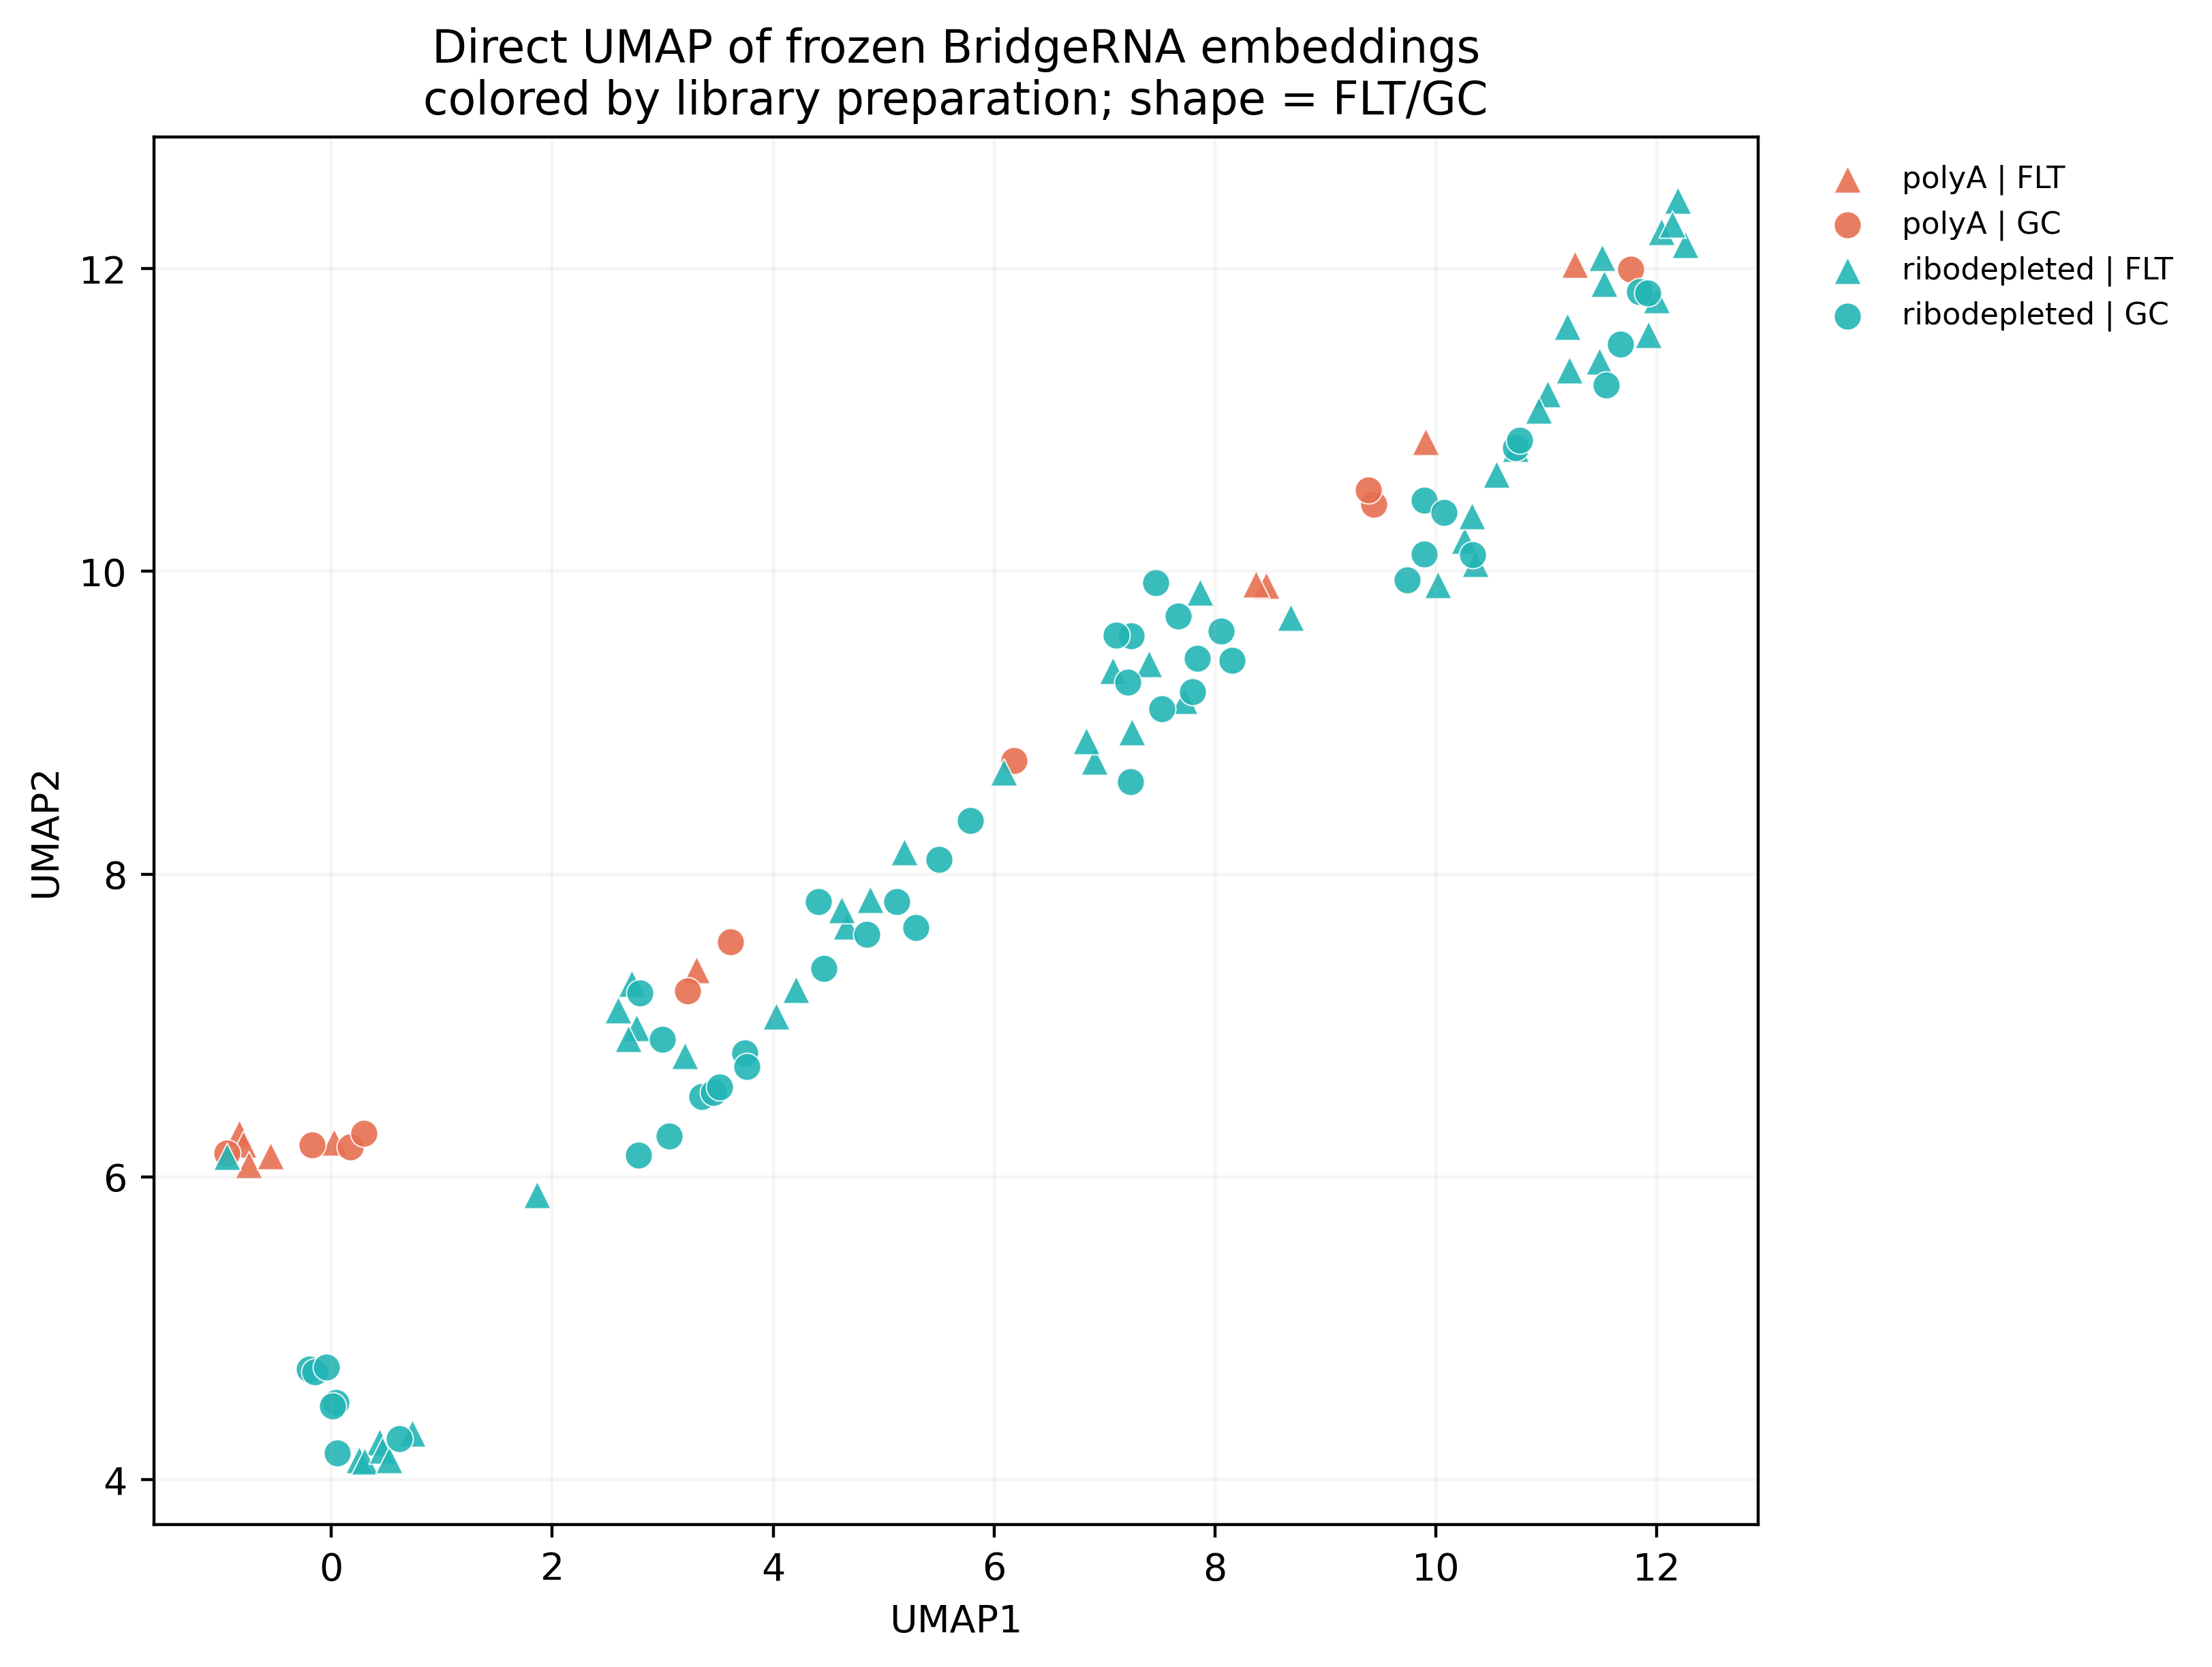

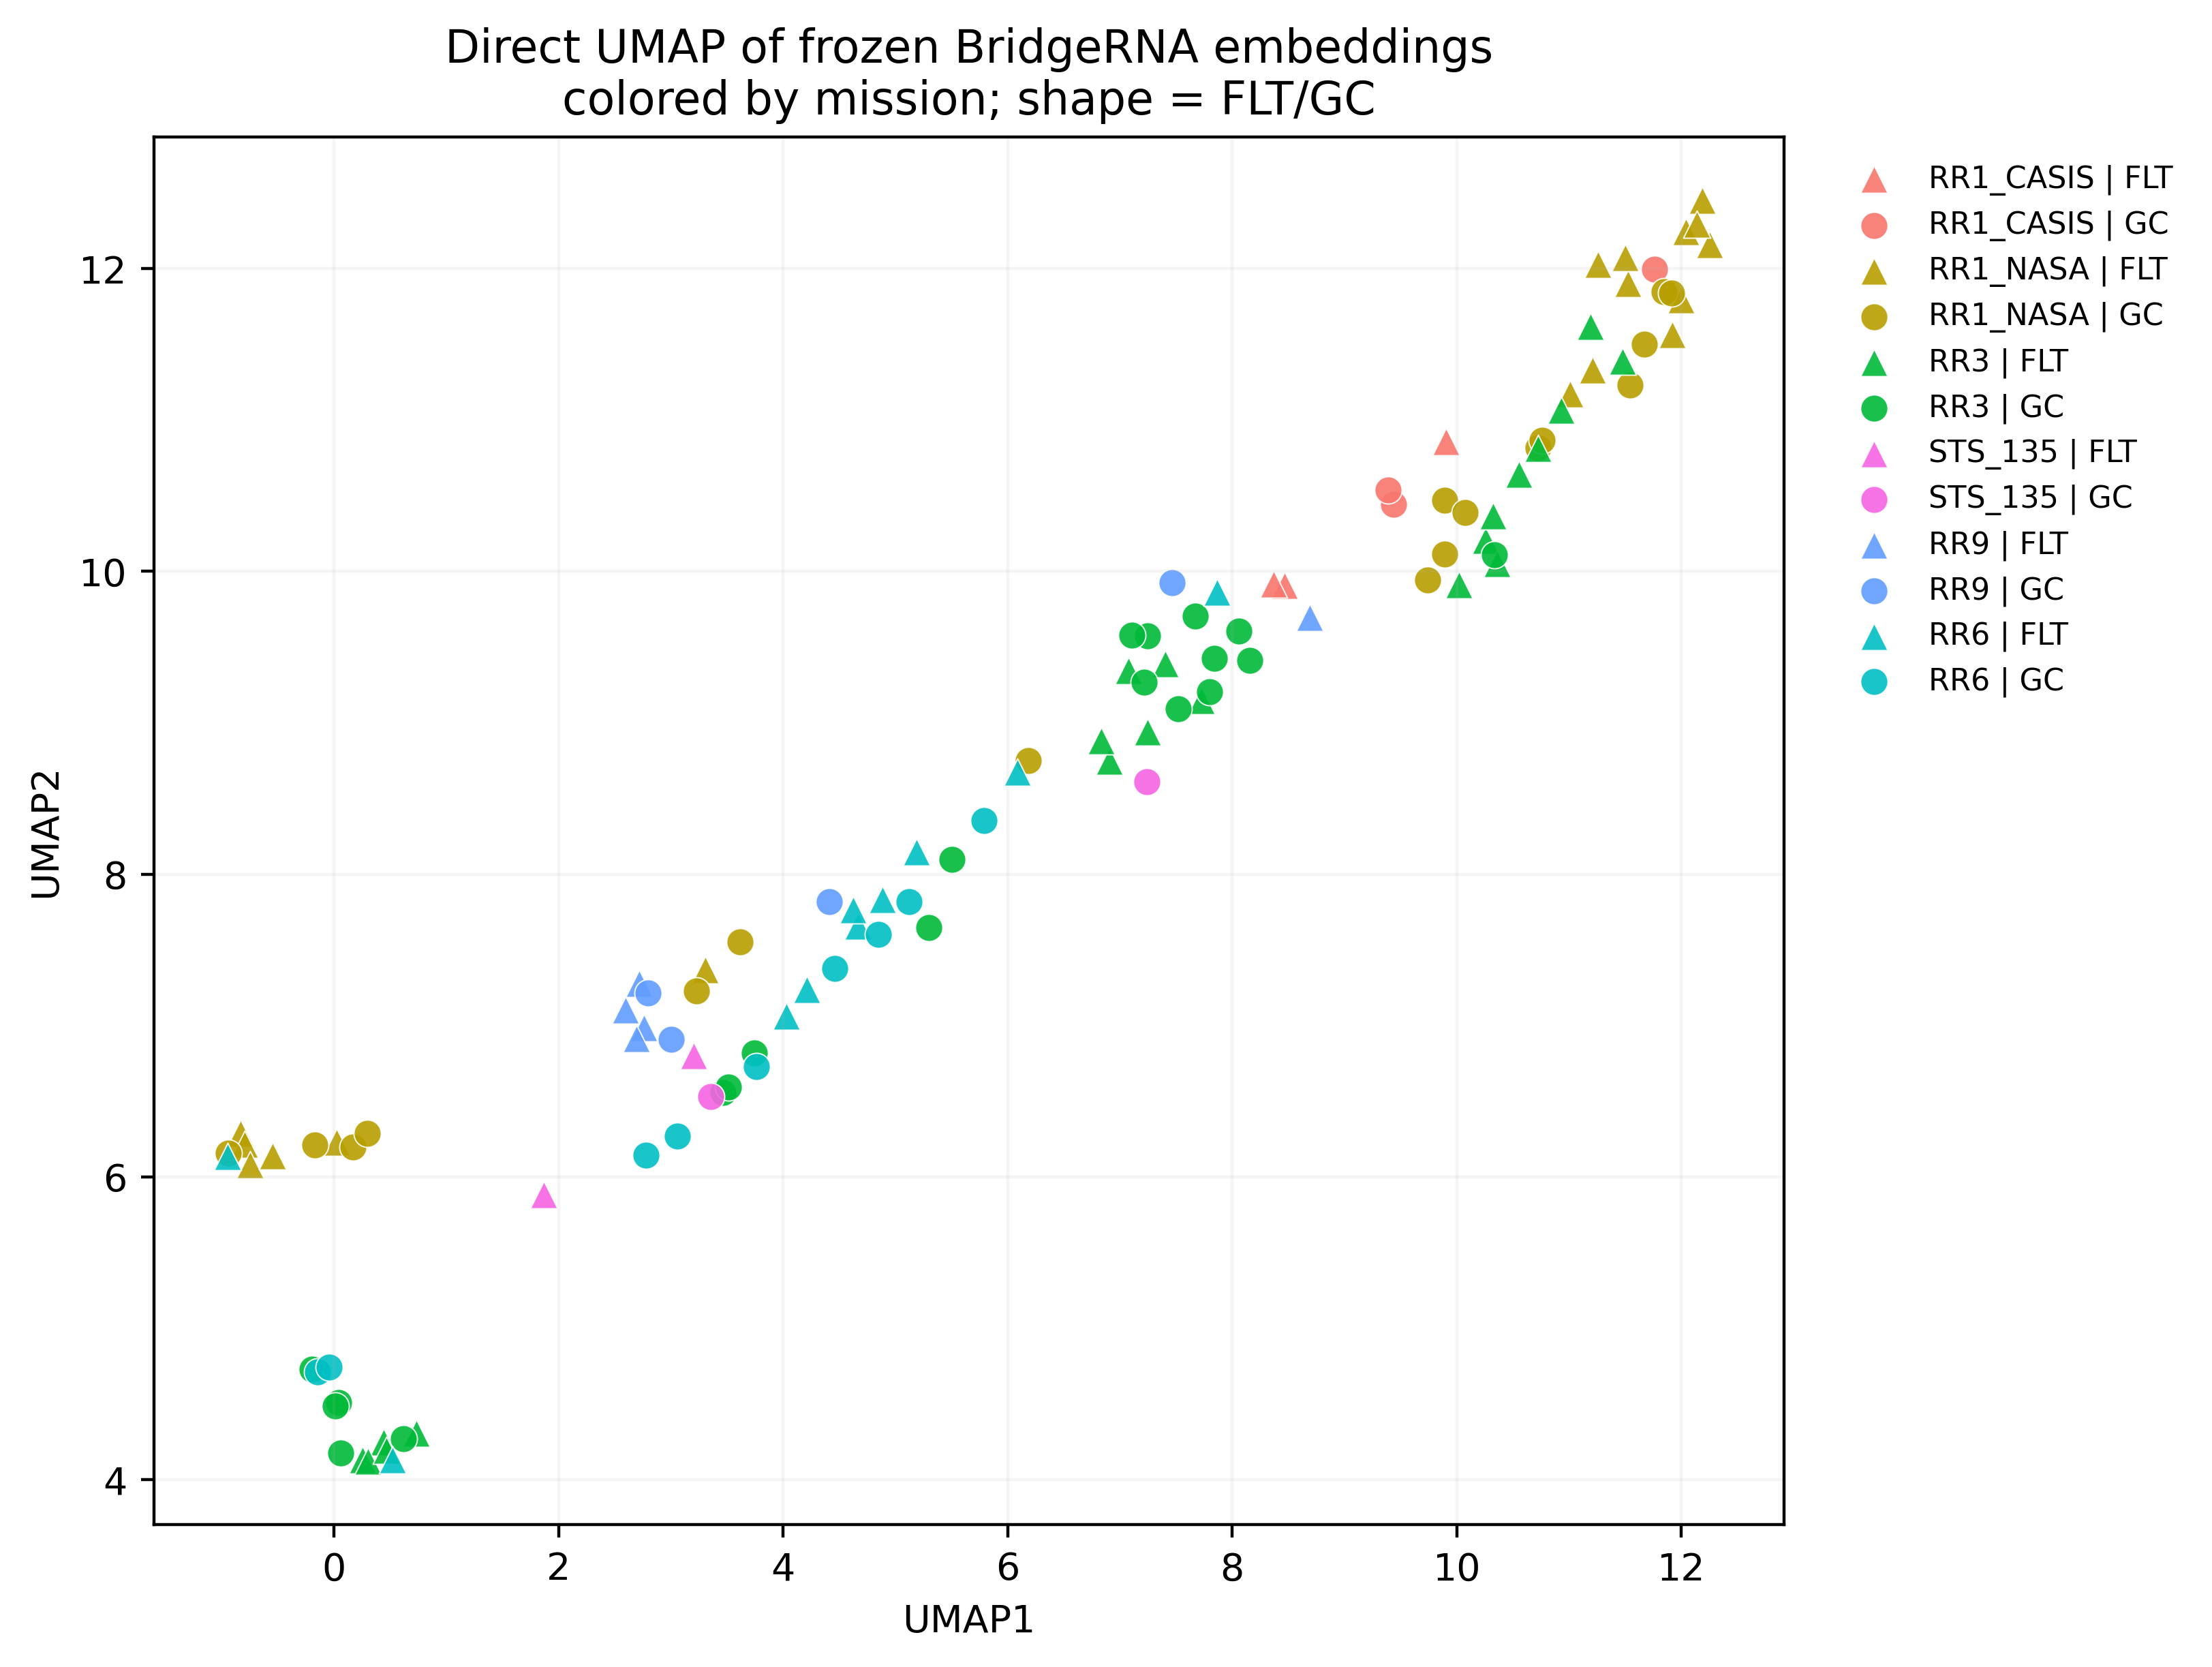

In [16]:
display(Image(filename=str(R / 'bridgerna_umap_library_preparation.png')))
display(Image(filename=str(R / 'bridgerna_umap_mission.png')))

## 6. Quantification of technical versus biological structure

Categorical R² is the fraction of total multivariate sum-of-squares lying between levels of each variable. The permutation p-value shuffles labels 999 times and is descriptive because study, mission, library protocol, facility, sequencing parameters, strain, and preservation are highly confounded. `condition` is the flight-versus-ground biological label.

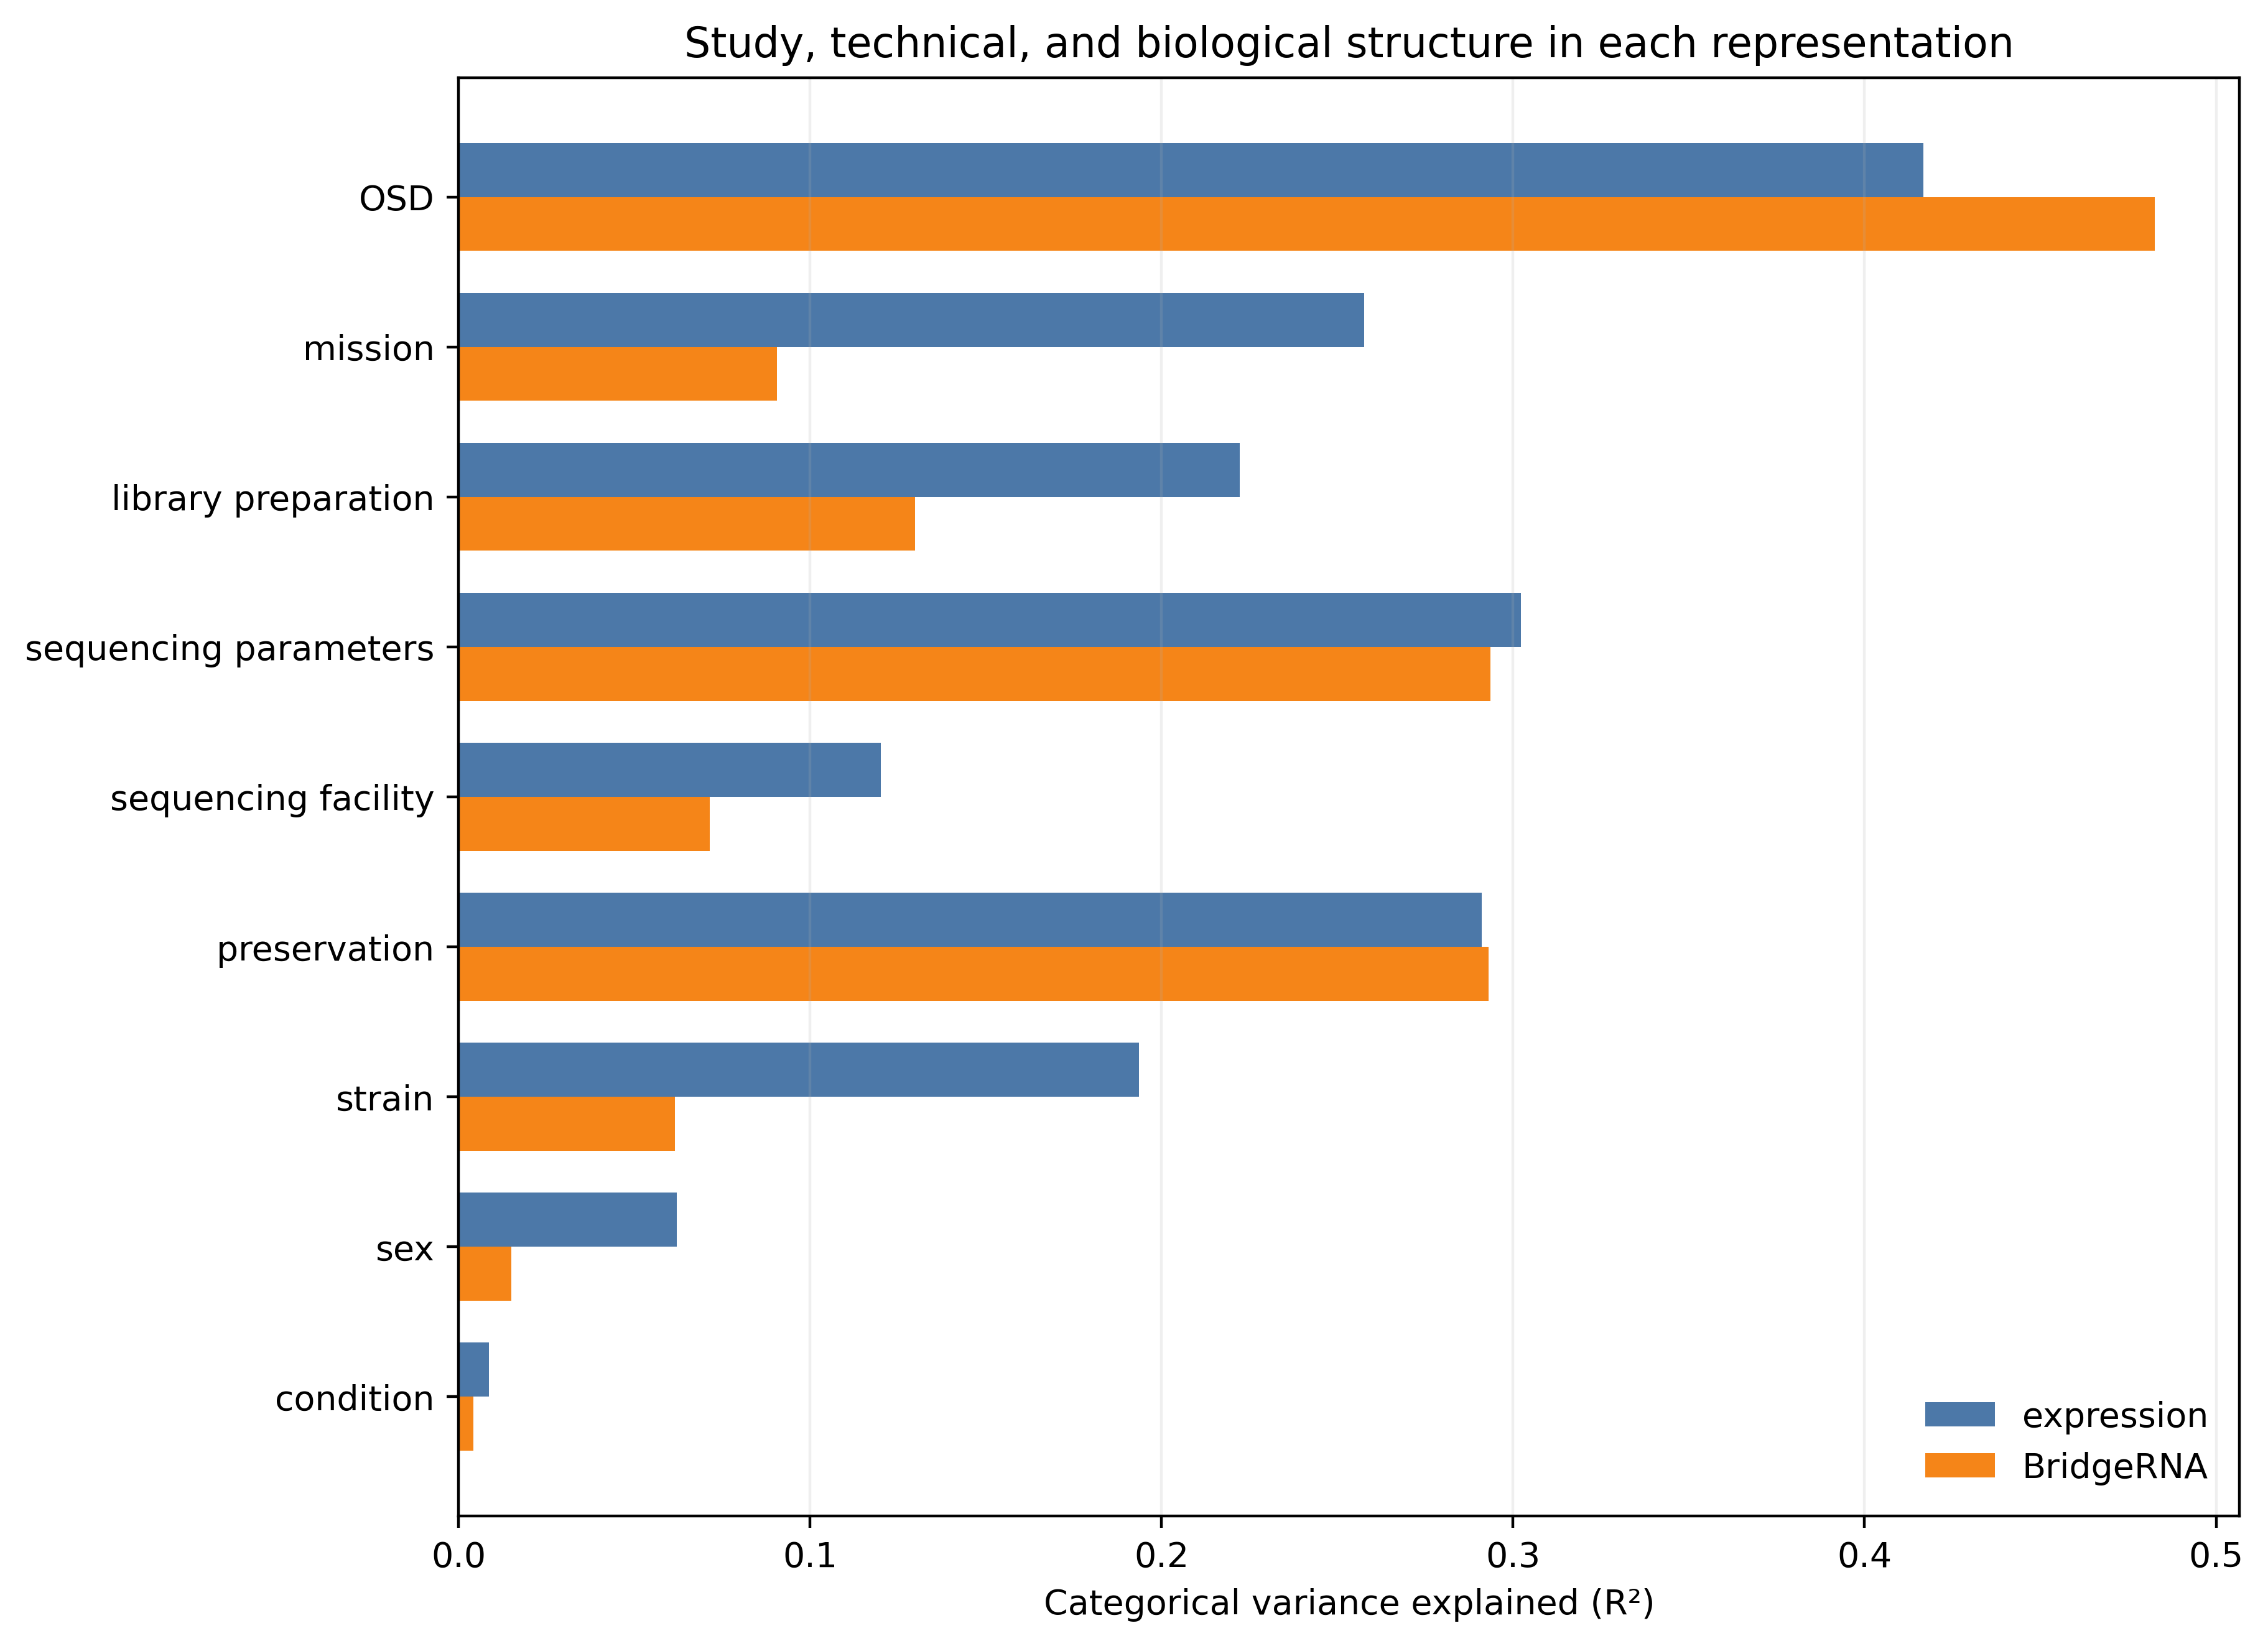

representation,BridgeRNA,expression
variable,,
OSD,0.483,0.417
sequencing_parameters,0.294,0.302
preservation,0.293,0.291
mission,0.091,0.258
library_preparation,0.130,0.222
strain,0.061,0.193
sequencing_facility,0.071,0.120
sex,0.015,0.062
condition,0.004,0.009


,representation,variable,categorical_r2,permutation_p,silhouette_pc1_pc10
0,expression,OSD,0.417,0.001,0.232
1,expression,mission,0.258,0.001,0.089
2,expression,library_preparation,0.222,0.001,0.421
3,expression,condition,0.009,0.429,-0.001
4,expression,sequencing_facility,0.120,0.001,0.186
5,expression,sequencing_parameters,0.302,0.001,0.279
6,expression,preservation,0.291,0.001,0.173
7,expression,strain,0.193,0.001,0.143
8,expression,sex,0.062,0.001,-0.016
9,BridgeRNA,OSD,0.483,0.001,-0.096


In [17]:
display(Image(filename=str(R / 'categorical_structure_comparison.png')))
wide = structure.pivot(index='variable',columns='representation',values='categorical_r2').sort_values('expression',ascending=False)
display(wide.style.format('{:.3f}'))
display(structure[['representation','variable','categorical_r2','permutation_p','silhouette_pc1_pc10']].style.format({'categorical_r2':'{:.3f}','permutation_p':'{:.3f}','silhouette_pc1_pc10':'{:.3f}'}))

### Which PCs carry each variable?

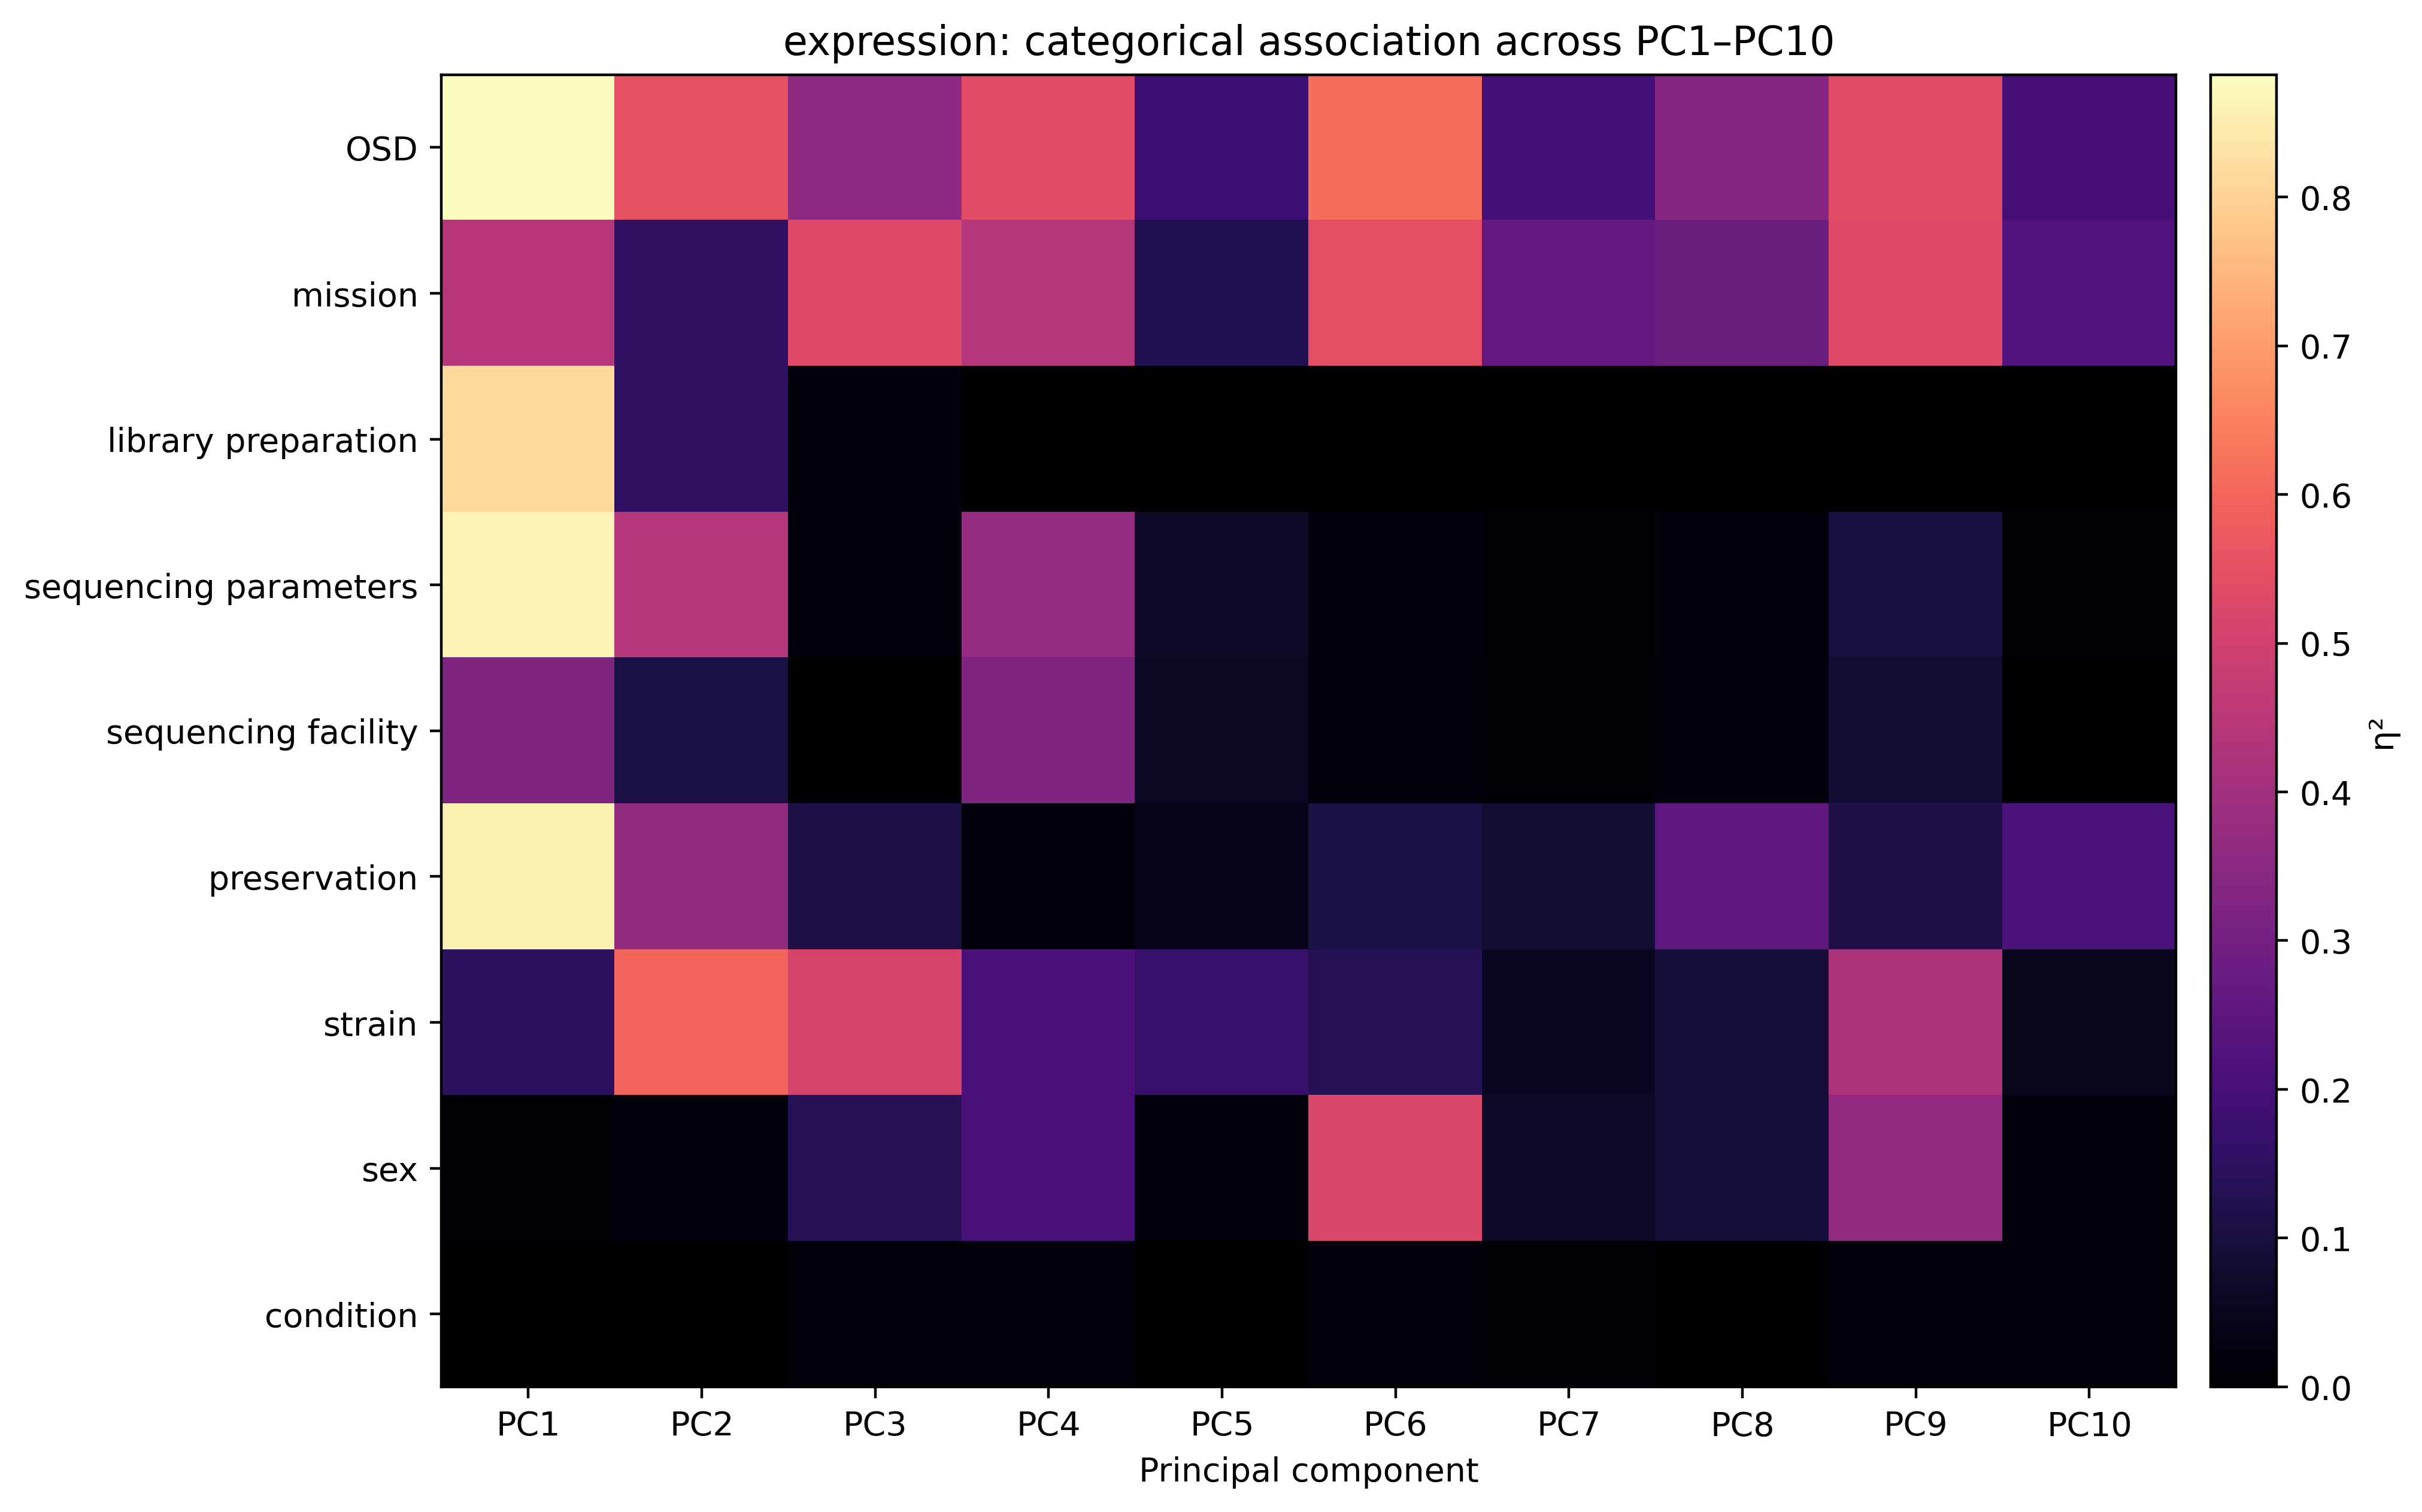

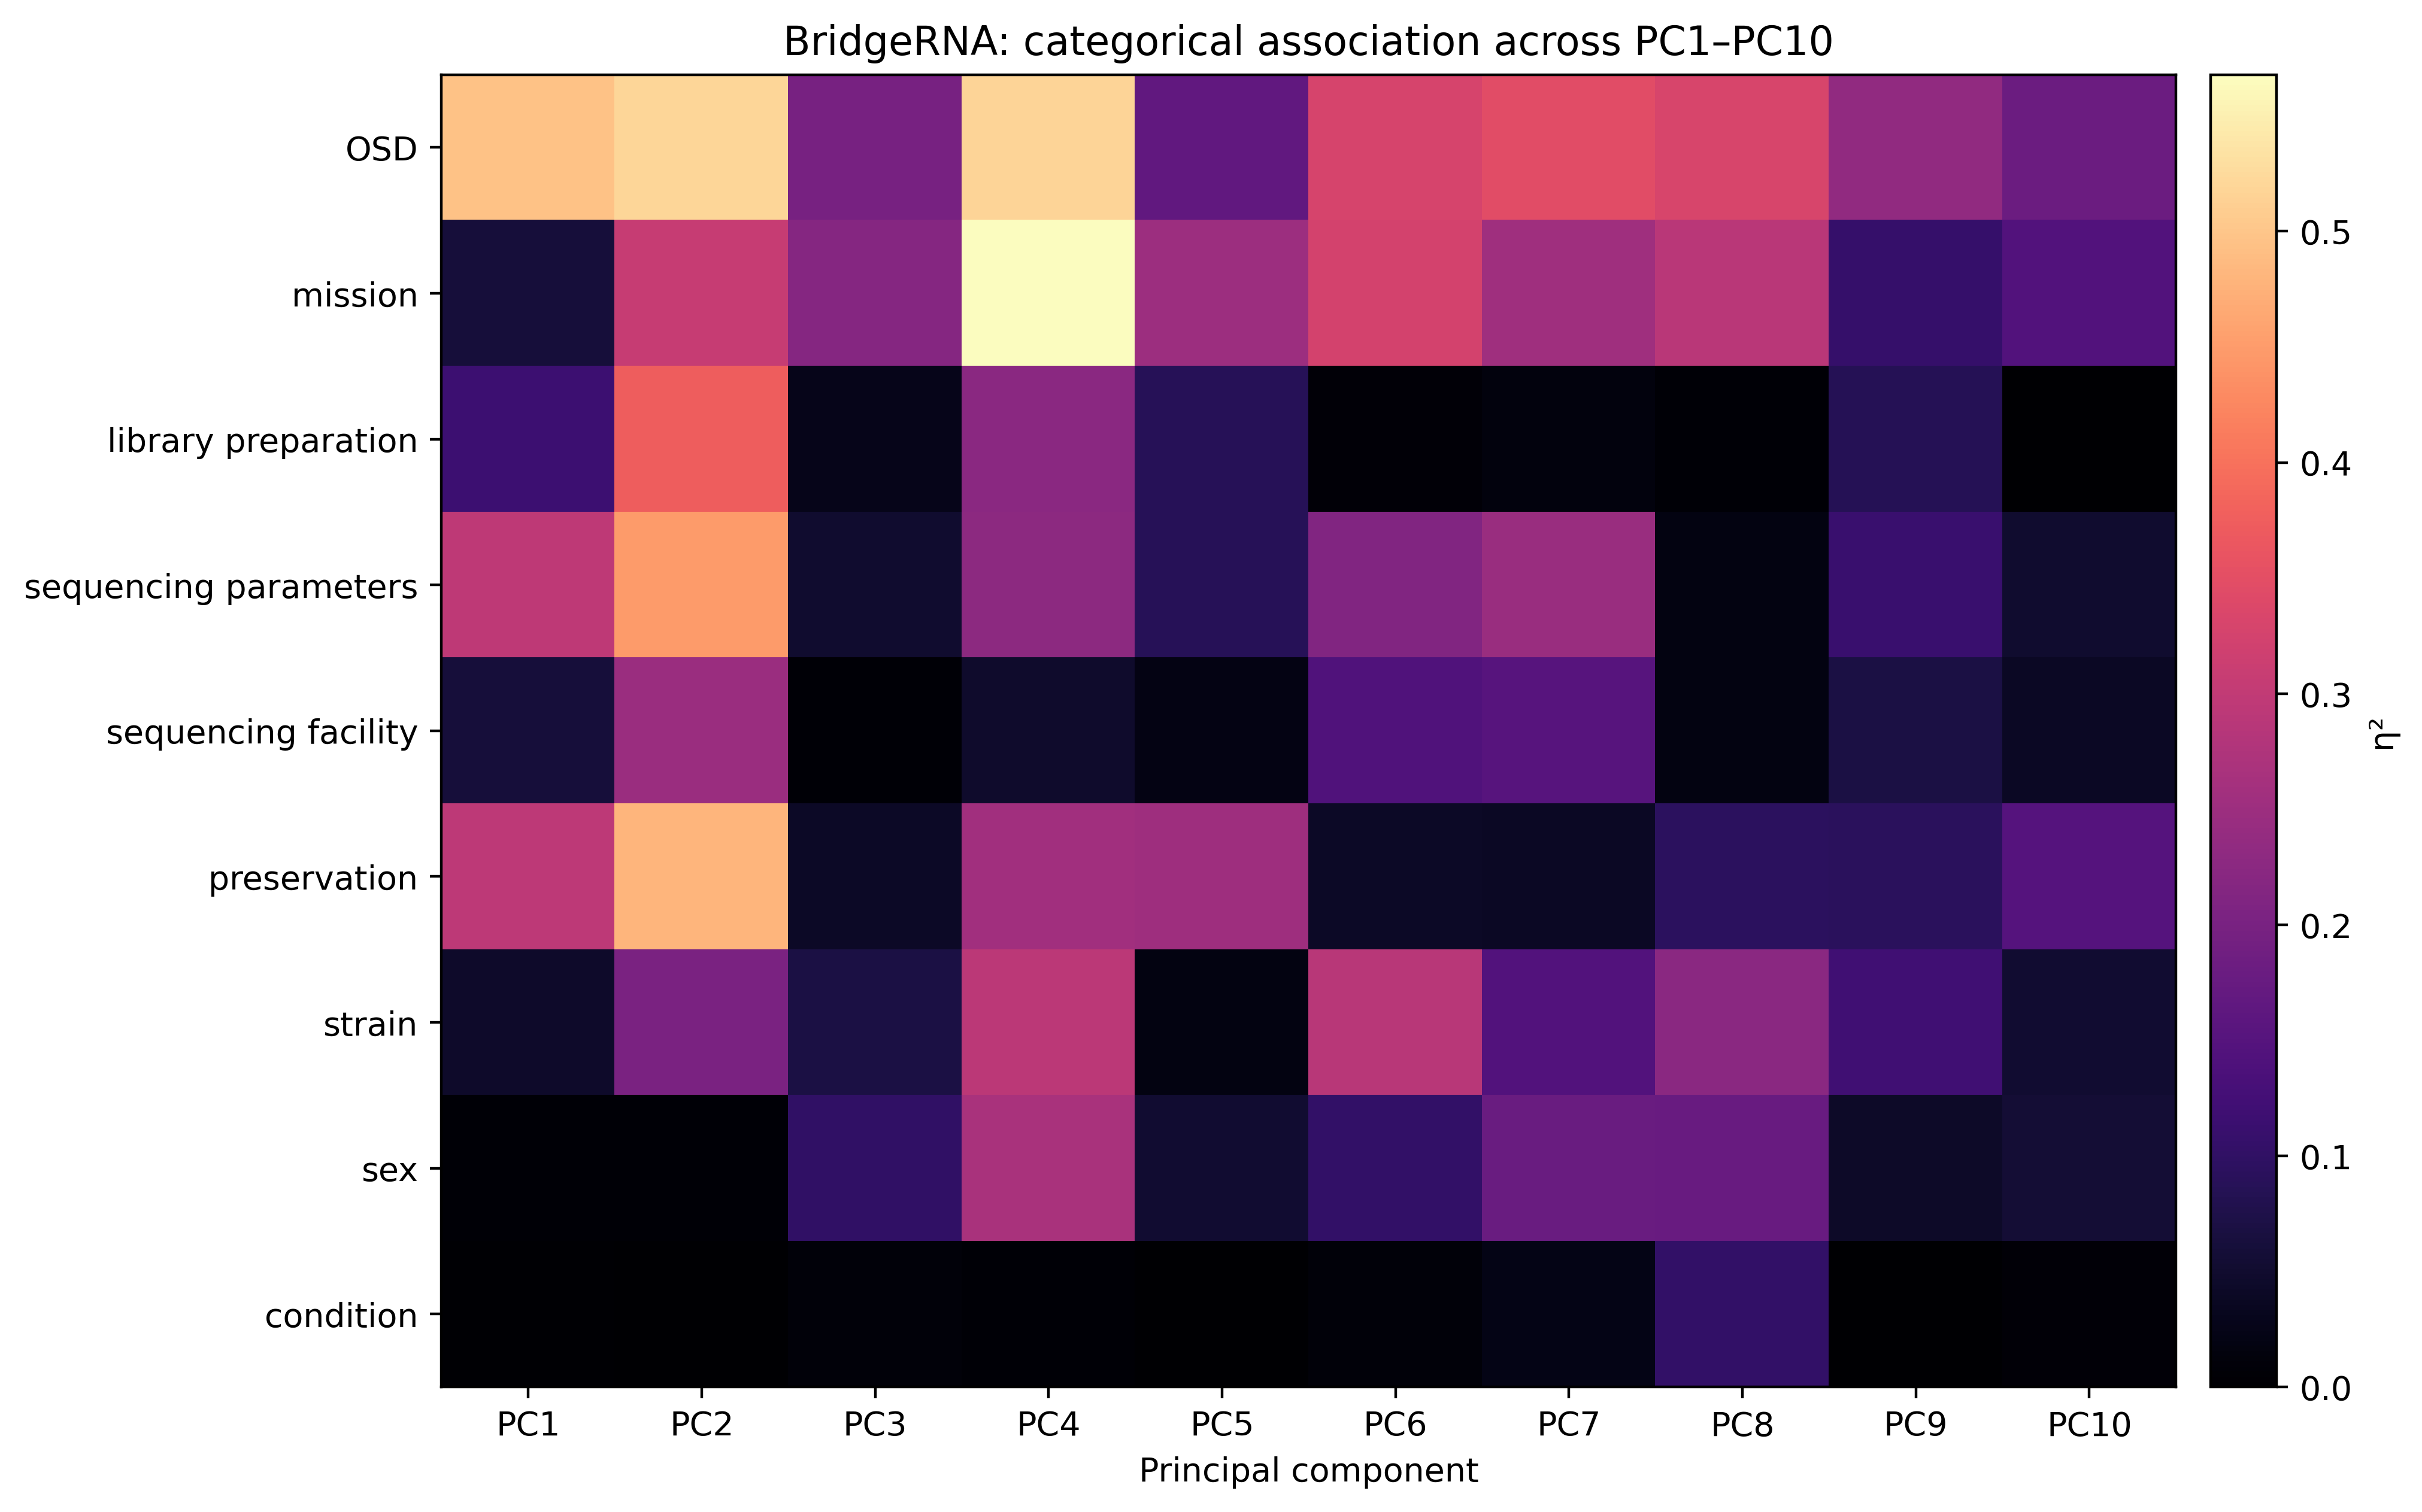

In [18]:
display(Image(filename=str(R / 'expression_pc_association_heatmap.png')))
display(Image(filename=str(R / 'bridgerna_pc_association_heatmap.png')))

## 7. Main conclusion

The corrected expression reproduction recovers the published PC variance closely after the explicitly disclosed `log2(normalized count + 1)` step. Both the published and local plots show that study-linked technical structure—especially library preparation, sequencing configuration, and mission—dominates flight-versus-ground separation.

BridgeRNA should not reproduce the paper's PC percentages because its PCA is performed on frozen 512-D embeddings rather than the normalized expression matrix. Its results test a different question: how much of the same technical and biological structure remains after frozen model encoding. The categorical R² table below provides that comparison without claiming that BridgeRNA performs batch correction.

Because study, mission, library protocol, facility, sequencing parameters, strain, and preservation are confounded, these R² values are descriptive marginal associations rather than causal decompositions.

## 8. Output inventory

In [19]:
files=[]
for p in sorted(R.iterdir()):
    if p.is_file(): files.append({'file':p.name,'size_MB':p.stat().st_size/1e6})
display(pd.DataFrame(files).style.format({'size_MB':'{:.2f}'}))

,file,size_MB
0,bridgerna_figure1_library_preparation.pdf,0.02
1,bridgerna_figure1_library_preparation.png,0.25
2,bridgerna_figure1_mission.pdf,0.02
3,bridgerna_figure1_mission.png,0.29
4,bridgerna_pc_association_heatmap.pdf,0.02
5,bridgerna_pc_association_heatmap.png,0.20
6,bridgerna_pca_coordinates.csv,0.03
7,bridgerna_pca_variance.csv,0.00
8,bridgerna_umap_coordinates.csv,0.01
9,bridgerna_umap_library_preparation.pdf,0.02
